# 1. Project Overview — Solar Power Generation and Air Quality Prediction in Saudi Arabia

**Team:** Atheer, Ritaj, Yasser, and Hussam

**Datasets:** KSA Weather Data, KSA Air Quality Data, and the
[KSA Solar Dataset](https://www.kaggle.com/datasets/shahlaliaquat/2024-solar-dataset-of-top-5-cities-of-ksa).

In this project, we wanted to see how weather and air quality data can be used to support solar energy decisions.

Our project answers three main questions:
1. How much solar energy can be produced each day?
2. What will the air quality be tomorrow, and what is the expected risk level?
3. Does adding air quality data improve the prediction compared to using weather data only?

# 2. Environment Setup




In [1]:
# Download the library for Data Manipulation and Visualization
import math
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Download the Modelling
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

# Download the Evaluation
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report,
    average_precision_score, ConfusionMatrixDisplay,
)


warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 3. Data Understanding

## 3.1 Dataset 1 — KSA Weather Data

### 3.1.1 Load the dataset



In [2]:
df_weather = pd.read_csv("/content/Weather_Dataset.csv")

### 3.1.2 Initial Data Audit



In [3]:
# show the first five rows
df_weather.head()

,Date,City,Latitude,Longitude,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_mean,wind_direction_10m_dominant,cloud_cover_mean,precipitation_sum,shortwave_radiation_sum,sunshine_duration
0,2024-01-01,Riyadh,24.7136,46.6753,17.9,73,947.6,11.0,117,18,0.0,14.37,36000.00
1,2024-01-02,Riyadh,24.7136,46.6753,17.1,73,946.9,15.0,132,34,0.0,14.35,34377.52
2,2024-01-03,Riyadh,24.7136,46.6753,18.3,63,944.5,15.1,17,12,0.1,14.32,36000.00
3,2024-01-04,Riyadh,24.7136,46.6753,14.8,67,947.5,9.8,24,3,0.0,15.07,36000.00
4,2024-01-05,Riyadh,24.7136,46.6753,15.0,63,947.3,6.2,53,3,0.0,14.94,36000.00


In [4]:
# show the number of rows and columns
print(f"KSA Weather Dataset shape: {df_weather.shape}")
print(f"Columns: {df_weather.columns.tolist() }")

KSA Weather Dataset shape: (1830, 13)
Columns: ['Date', 'City', 'Latitude', 'Longitude', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'wind_speed_10m_mean', 'wind_direction_10m_dominant', 'cloud_cover_mean', 'precipitation_sum', 'shortwave_radiation_sum', 'sunshine_duration']


In [5]:
# show dataset information
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1830 entries, 0 to 1829
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         1830 non-null   object 
 1   City                         1830 non-null   object 
 2   Latitude                     1830 non-null   float64
 3   Longitude                    1830 non-null   float64
 4   temperature_2m_mean          1830 non-null   float64
 5   relative_humidity_2m_mean    1830 non-null   int64  
 6   surface_pressure_mean        1830 non-null   float64
 7   wind_speed_10m_mean          1830 non-null   float64
 8   wind_direction_10m_dominant  1830 non-null   int64  
 9   cloud_cover_mean             1830 non-null   int64  
 10  precipitation_sum            1830 non-null   float64
 11  shortwave_radiation_sum      1830 non-null   float64
 12  sunshine_duration            1830 non-null   float64
dtypes: float64(8), int

In [6]:
# Show summary of all columns in the dataset
df_weather.describe(include="all")

,Date,City,Latitude,Longitude,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_mean,wind_direction_10m_dominant,cloud_cover_mean,precipitation_sum,shortwave_radiation_sum,sunshine_duration
count,1830,1830,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.00000,1830.000000,1830.000000,1830.000000
unique,366,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-12-31,Riyadh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,23.706780,43.076740,28.398415,42.529508,975.817377,13.680383,239.803279,24.65082,0.338415,20.988448,38809.148137
std,NaN,NaN,1.967893,4.470443,6.520832,19.846953,29.647883,4.820456,102.829237,27.37790,2.155298,4.470207,5137.709426
min,NaN,NaN,21.389100,39.192500,10.700000,7.000000,930.200000,2.300000,0.000000,0.00000,0.000000,3.960000,0.000000
25%,NaN,NaN,21.485800,39.569200,23.600000,25.000000,945.300000,10.300000,155.250000,1.00000,0.000000,16.922500,36229.465000
50%,NaN,NaN,24.524700,39.857900,28.900000,43.000000,976.250000,13.200000,274.000000,15.00000,0.000000,21.745000,39600.000000
75%,NaN,NaN,24.713600,46.675300,34.100000,59.000000,1005.700000,16.400000,328.000000,41.00000,0.000000,25.045000,42198.120000


In [7]:
# show data types
df_weather.dtypes

,0
Date,object
City,object
Latitude,float64
Longitude,float64
temperature_2m_mean,float64
relative_humidity_2m_mean,int64
surface_pressure_mean,float64
wind_speed_10m_mean,float64
wind_direction_10m_dominant,int64
cloud_cover_mean,int64


In [8]:
# Count the number of unique values in each columns
df_weather.nunique()

,0
Date,366
City,5
Latitude,5
Longitude,5
temperature_2m_mean,268
relative_humidity_2m_mean,82
surface_pressure_mean,585
wind_speed_10m_mean,239
wind_direction_10m_dominant,347
cloud_cover_mean,101


In [9]:
# Check for the missing values
missing = df_weather.isnull().sum()
missing_pct = ( df_weather.isnull().sum() / len(df_weather) * 100).round(2)
missing_table = pd.DataFrame({ "Missing Count": missing, "Missing Percentage": missing_pct})
missing_table.sort_values( by="Missing Count", ascending=False)

,Missing Count,Missing Percentage
Date,0,0.0
City,0,0.0
Latitude,0,0.0
Longitude,0,0.0
temperature_2m_mean,0,0.0
relative_humidity_2m_mean,0,0.0
surface_pressure_mean,0,0.0
wind_speed_10m_mean,0,0.0
wind_direction_10m_dominant,0,0.0
cloud_cover_mean,0,0.0


In [10]:
# Check for duplicate rows in all the dataset
print("Duplicate rows:", df_weather.duplicated().sum())

Duplicate rows: 0


### 3.1.3 Exploratory Data Analysis




In [11]:
for columns in df_weather.columns:
    print(columns)

Date
City
Latitude
Longitude
temperature_2m_mean
relative_humidity_2m_mean
surface_pressure_mean
wind_speed_10m_mean
wind_direction_10m_dominant
cloud_cover_mean
precipitation_sum
shortwave_radiation_sum
sunshine_duration


In [12]:
df_weather['City'].value_counts()

,count
City,
Riyadh,366
Jeddah,366
Mecca,366
Medina,366
Dammam,366


In [13]:
print('Start date',df_weather['Date'].min())
print('End date',df_weather['Date'].max())

Start date 2024-01-01
End date 2024-12-31


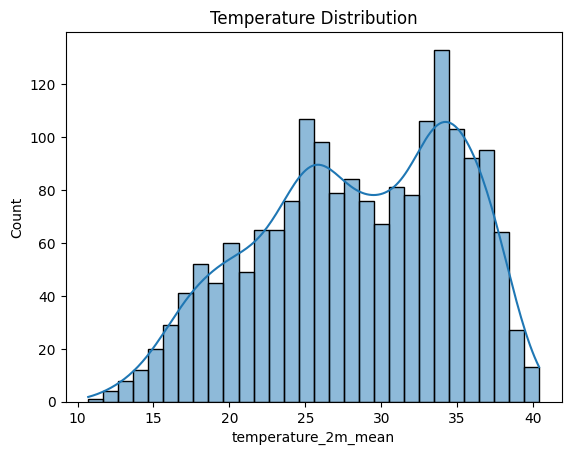

In [14]:
sns.histplot(data=df_weather,x='temperature_2m_mean',bins=30,kde=True)
plt.title('Temperature Distribution')
plt.show()

#Temperature Distribution to know if most days hot and if there any abnormal value

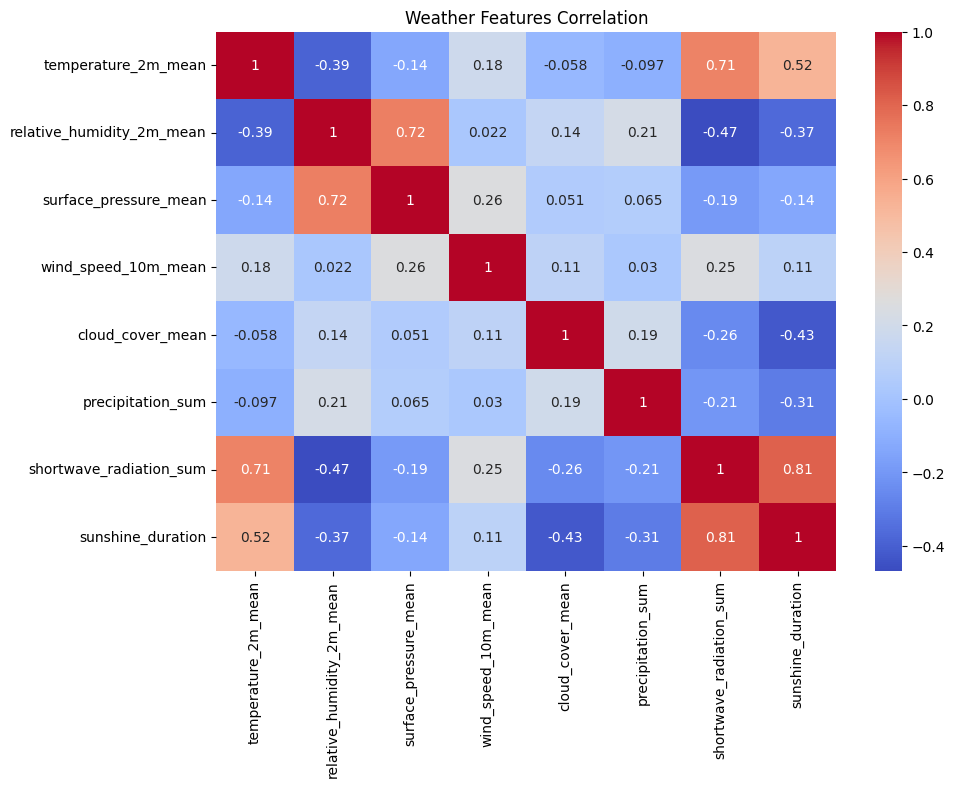

In [15]:
#if the cloud cover reduce solar radiation when it increases and is humidity related to rainfall
weather_features = [
    'temperature_2m_mean',
    'relative_humidity_2m_mean',
    'surface_pressure_mean',
    'wind_speed_10m_mean',
    'cloud_cover_mean',
    'precipitation_sum',
    'shortwave_radiation_sum',
    'sunshine_duration']
plt.figure(figsize=(10, 7))
sns.heatmap(df_weather[weather_features].corr(),annot=True,cmap="coolwarm")
plt.title("Weather Features Correlation")
plt.show()

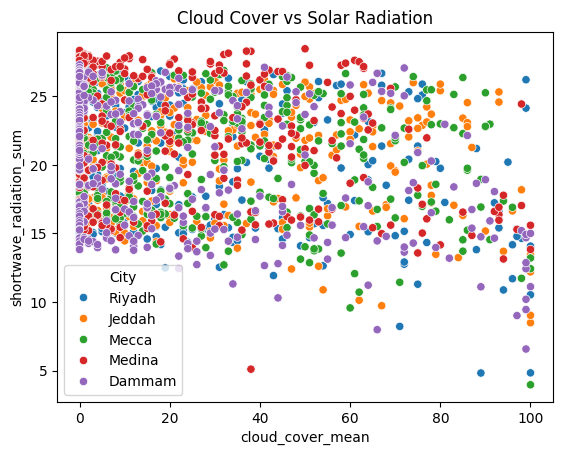

In [16]:
sns.scatterplot(data=df_weather,x="cloud_cover_mean",y="shortwave_radiation_sum",hue='City')
plt.title('Cloud Cover vs Solar Radiation')
plt.show()

### 3.1.4 Cleaning and Validation




In [17]:
numeric=df_weather.select_dtypes(include=['int64','float64']).columns

for column in numeric:
    Q1=df_weather[column].quantile(0.25)
    Q3=df_weather[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outlier=df_weather[(df_weather[column]<lower)|(df_weather[column]>upper)]

    if len(outlier)>0:
        print(column ,":" ,len(outlier),"outliers")

wind_speed_10m_mean : 31 outliers
precipitation_sum : 211 outliers
shortwave_radiation_sum : 1 outliers
sunshine_duration : 49 outliers


In [18]:
df_weather['Date']=pd.to_datetime(df_weather['Date'],errors="coerce")

In [19]:
print("KSA Weather Dataset shape after clean:", df_weather.shape)
df_weather.head()

KSA Weather Dataset shape after clean: (1830, 13)


,Date,City,Latitude,Longitude,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_mean,wind_direction_10m_dominant,cloud_cover_mean,precipitation_sum,shortwave_radiation_sum,sunshine_duration
0,2024-01-01,Riyadh,24.7136,46.6753,17.9,73,947.6,11.0,117,18,0.0,14.37,36000.00
1,2024-01-02,Riyadh,24.7136,46.6753,17.1,73,946.9,15.0,132,34,0.0,14.35,34377.52
2,2024-01-03,Riyadh,24.7136,46.6753,18.3,63,944.5,15.1,17,12,0.1,14.32,36000.00
3,2024-01-04,Riyadh,24.7136,46.6753,14.8,67,947.5,9.8,24,3,0.0,15.07,36000.00
4,2024-01-05,Riyadh,24.7136,46.6753,15.0,63,947.3,6.2,53,3,0.0,14.94,36000.00



We checked the weather dataset and verified that the dates were aligned correctly. outlier values were kept because they could represent actual weather conditions

## 3.2 Dataset 2 — KSA Air Quality Data

### 3.2.1 Load the dataset




In [20]:
df_air = pd.read_csv("/content/AirQuality_Dataset.csv")

### 3.2.2 Initial Data Audit




In [21]:
# show the first five rows
df_air.head()

,Date,City,Latitude,Longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,sulphur_dioxide,us_aqi
0,2024-01-01,Riyadh,24.7136,46.6753,200.862500,38.658333,263.125000,37.154167,46.208333,55.258333,115.250000
1,2024-01-02,Riyadh,24.7136,46.6753,286.479167,47.554167,228.708333,25.579167,51.500000,48.712500,138.166667
2,2024-01-03,Riyadh,24.7136,46.6753,434.533333,50.437500,231.250000,22.870833,45.083333,46.829167,163.958333
3,2024-01-04,Riyadh,24.7136,46.6753,105.216667,27.787500,215.750000,31.012500,47.083333,43.212500,267.958333
4,2024-01-05,Riyadh,24.7136,46.6753,70.895833,31.858333,300.791667,45.891667,24.000000,86.200000,83.166667


In [22]:
print(f"KSA Air Quality Dataset shape: {df_air.shape}")
print(f"Columns: {df_air.columns.tolist() }")

KSA Air Quality Dataset shape: (1830, 11)
Columns: ['Date', 'City', 'Latitude', 'Longitude', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'us_aqi']


In [23]:
# show dataset information
df_air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1830 entries, 0 to 1829
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1830 non-null   object 
 1   City              1830 non-null   object 
 2   Latitude          1830 non-null   float64
 3   Longitude         1830 non-null   float64
 4   pm10              1830 non-null   float64
 5   pm2_5             1830 non-null   float64
 6   carbon_monoxide   1830 non-null   float64
 7   nitrogen_dioxide  1830 non-null   float64
 8   ozone             1830 non-null   float64
 9   sulphur_dioxide   1830 non-null   float64
 10  us_aqi            1830 non-null   float64
dtypes: float64(9), object(2)
memory usage: 157.4+ KB


In [24]:
# Show summary of all columns in the dataset
df_air.describe(include="all")

,Date,City,Latitude,Longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,sulphur_dioxide,us_aqi
count,1830,1830,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000
unique,366,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-12-31,Riyadh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,23.706780,43.076740,208.946592,38.079879,204.540597,23.080943,78.822199,40.840016,160.576503
std,NaN,NaN,1.967893,4.470443,273.561771,28.073497,74.620281,13.105669,28.148772,28.513639,221.664696
min,NaN,NaN,21.389100,39.192500,19.775000,8.583333,118.708333,1.295833,17.083333,1.937500,51.833333
25%,NaN,NaN,21.485800,39.569200,82.315625,22.545833,160.770833,13.092708,60.958333,21.817708,80.479167
50%,NaN,NaN,24.524700,39.857900,136.822917,30.895833,184.208333,20.708333,74.604167,32.785417,106.291667
75%,NaN,NaN,24.713600,46.675300,236.177083,44.650000,223.145833,31.115625,92.416667,50.763542,152.562500


In [25]:
# show data types
df_air.dtypes

,0
Date,object
City,object
Latitude,float64
Longitude,float64
pm10,float64
pm2_5,float64
carbon_monoxide,float64
nitrogen_dioxide,float64
ozone,float64
sulphur_dioxide,float64


In [26]:
# Count the number of unique values in each columns
df_air.nunique()

,0
Date,366
City,5
Latitude,5
Longitude,5
pm10,1815
pm2_5,1705
carbon_monoxide,1432
nitrogen_dioxide,1679
ozone,1241
sulphur_dioxide,1715


In [27]:
# Check for the missing values
missing = df_air.isnull().sum()
missing_pct = ( df_air.isnull().sum() / len(df_air) * 100).round(2)
missing_table = pd.DataFrame({ "Missing Count": missing, "Missing Percentage": missing_pct})
missing_table.sort_values( by="Missing Count", ascending=False)

,Missing Count,Missing Percentage
Date,0,0.0
City,0,0.0
Latitude,0,0.0
Longitude,0,0.0
pm10,0,0.0
pm2_5,0,0.0
carbon_monoxide,0,0.0
nitrogen_dioxide,0,0.0
ozone,0,0.0
sulphur_dioxide,0,0.0


In [28]:
# Check for duplicate rows in all the dataset
print("Duplicate rows:", df_air.duplicated().sum())

Duplicate rows: 0


### 3.2.3 Exploratory Data Analysis




In [29]:
for columns in df_air.columns:
    print(columns)

Date
City
Latitude
Longitude
pm10
pm2_5
carbon_monoxide
nitrogen_dioxide
ozone
sulphur_dioxide
us_aqi


In [30]:
# Count the City distribution
df_air['City'].value_counts()

,count
City,
Riyadh,366
Jeddah,366
Mecca,366
Medina,366
Dammam,366


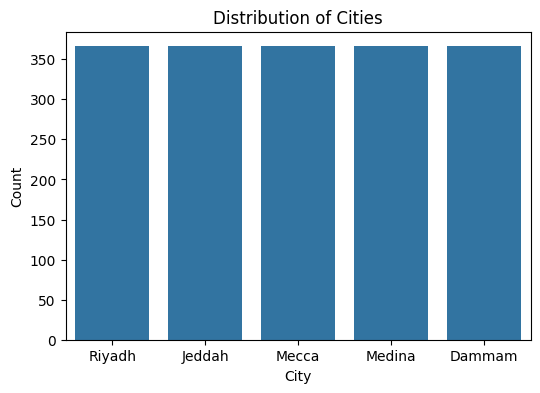

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_air, x="City")
plt.title("Distribution of Cities")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

In [32]:
# show the time period covered by the dataset
print('Start date',df_air['Date'].min())
print('End date',df_air['Date'].max())

Start date 2024-01-01
End date 2024-12-31


In [33]:
# Select the air quality features
air_features = [
    'pm10',
    'pm2_5',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'ozone',
    'sulphur_dioxide',
    'us_aqi']

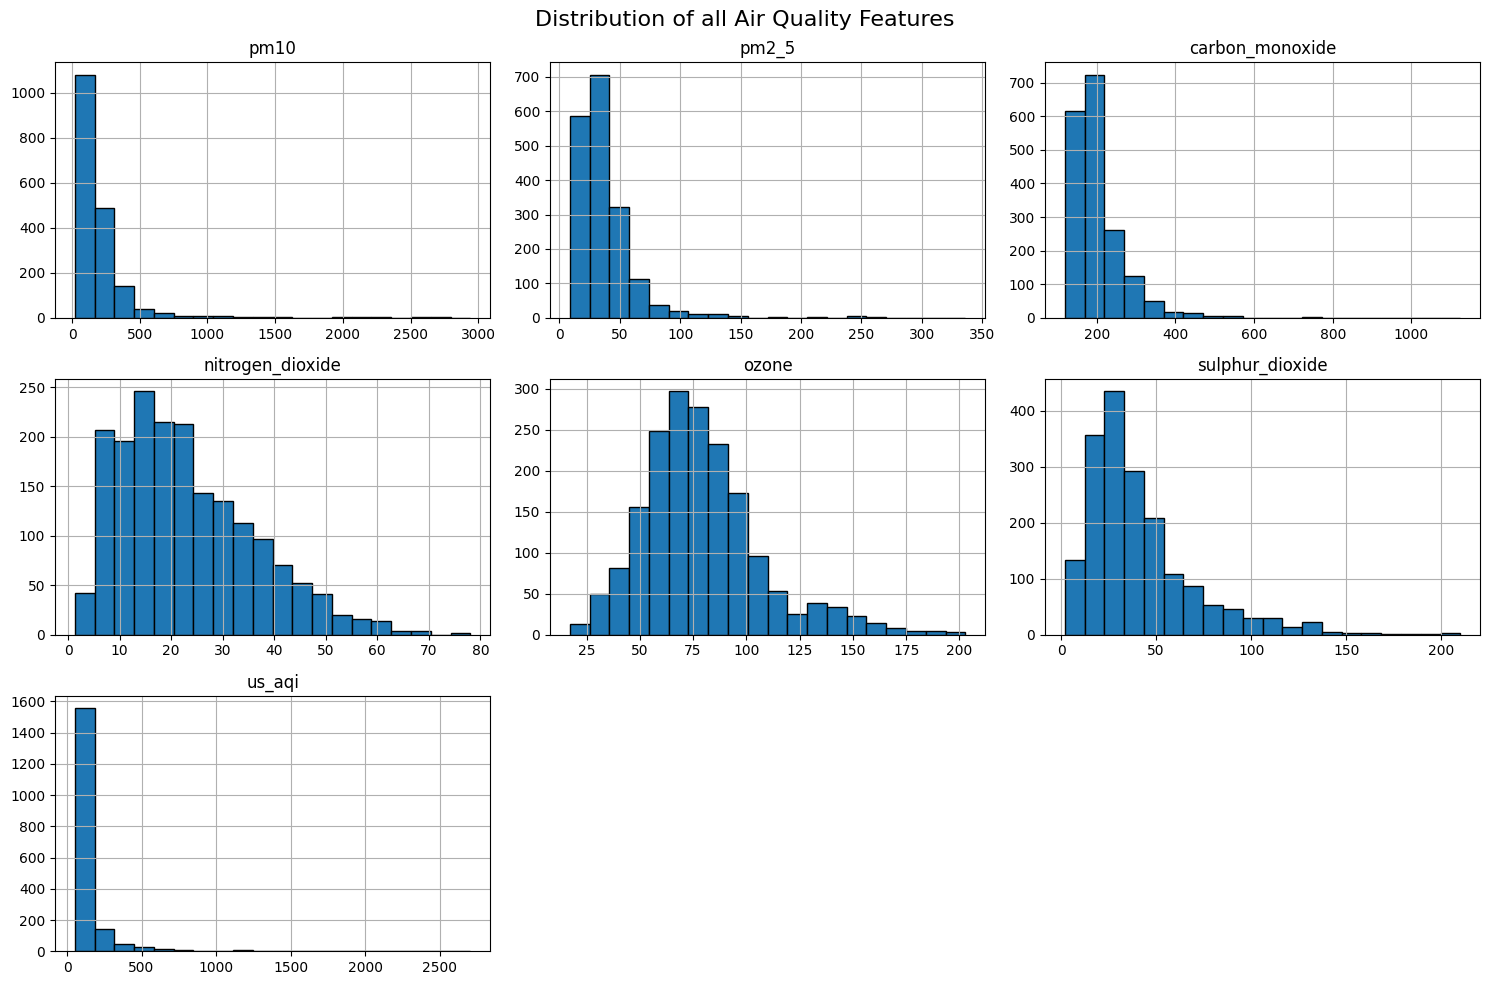

In [34]:
#edgecolor="black" to show each columns clearly
# show the Histogram for all air quality features
df_air[air_features].hist(figsize=(15, 10), bins=20, edgecolor="black")

plt.suptitle("Distribution of all Air Quality Features", fontsize=16)
plt.tight_layout()
plt.show()

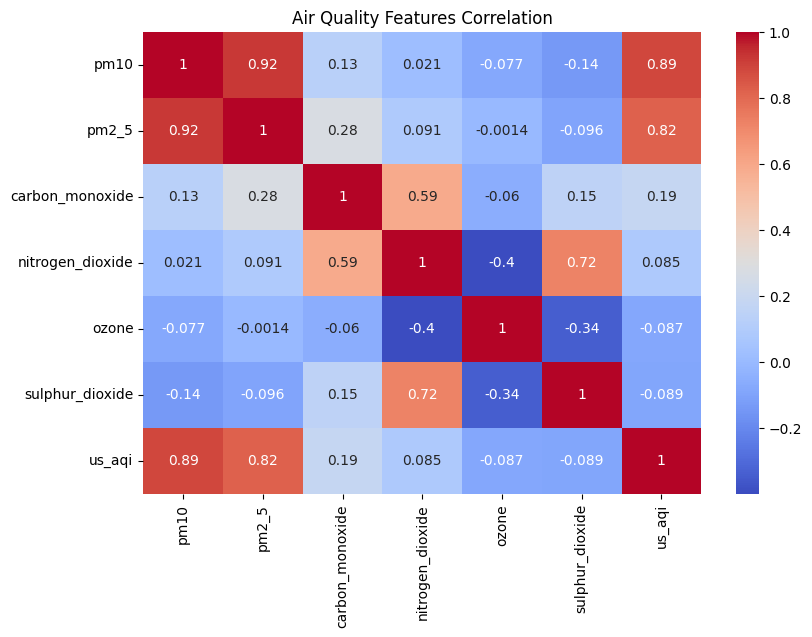

In [35]:
#to know which pollutants move together and which of them drive the US AQI
plt.figure(figsize=(9, 6))
sns.heatmap(df_air[air_features].corr(),annot=True,cmap="coolwarm")
plt.title("Air Quality Features Correlation")
plt.show()

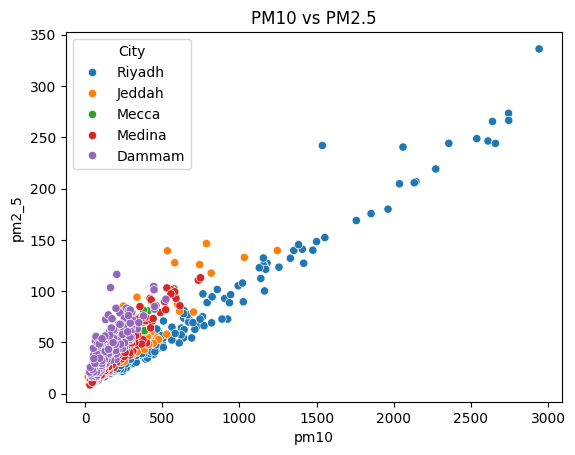

In [36]:
#PM10 vs PM2.5 to see if dust days raise both particle sizes together
sns.scatterplot(data=df_air,x="pm10",y="pm2_5",hue='City')
plt.title('PM10 vs PM2.5')
plt.show()

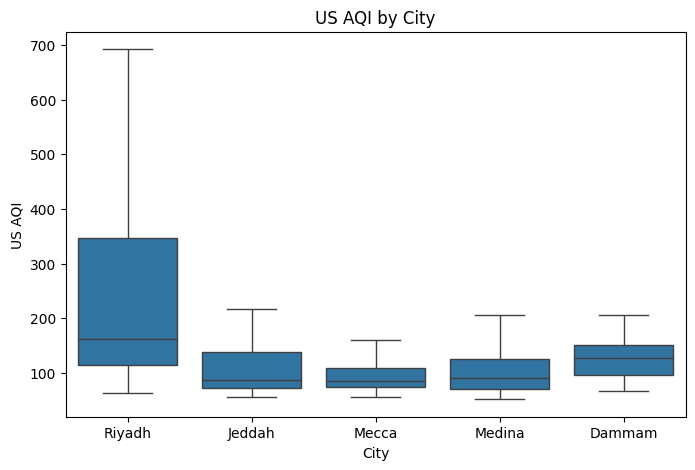

In [37]:
# Compare the US AQI between the cities
plt.figure(figsize=(8,5))
sns.boxplot(data=df_air, x="City", y="us_aqi", showfliers=False)
plt.title("US AQI by City")
plt.xlabel("City")
plt.ylabel("US AQI")
plt.show()

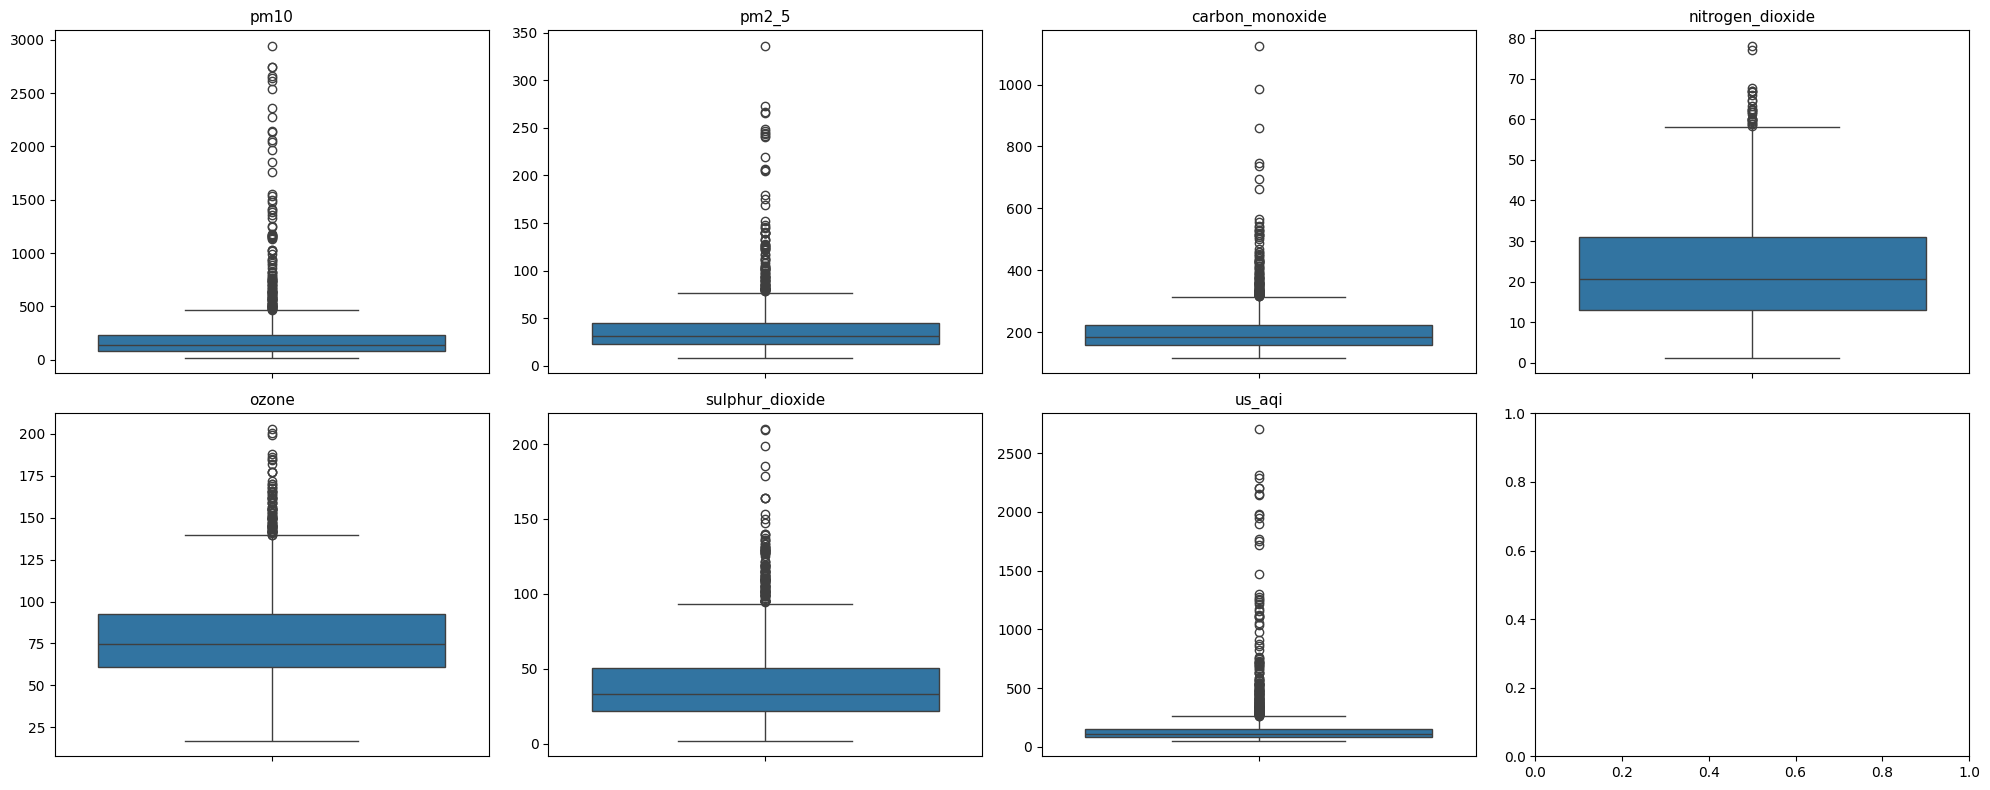

In [38]:
n_cols = 4
n_rows = math.ceil(len(air_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(air_features):
    sns.boxplot(y=df_air[col], ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### 3.2.4 Cleaning and Validation



In [39]:
print("KSA Air Quality Dataset shape after clean:", df_air.shape)
df_air.head()

KSA Air Quality Dataset shape after clean: (1830, 11)


,Date,City,Latitude,Longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,sulphur_dioxide,us_aqi
0,2024-01-01,Riyadh,24.7136,46.6753,200.862500,38.658333,263.125000,37.154167,46.208333,55.258333,115.250000
1,2024-01-02,Riyadh,24.7136,46.6753,286.479167,47.554167,228.708333,25.579167,51.500000,48.712500,138.166667
2,2024-01-03,Riyadh,24.7136,46.6753,434.533333,50.437500,231.250000,22.870833,45.083333,46.829167,163.958333
3,2024-01-04,Riyadh,24.7136,46.6753,105.216667,27.787500,215.750000,31.012500,47.083333,43.212500,267.958333
4,2024-01-05,Riyadh,24.7136,46.6753,70.895833,31.858333,300.791667,45.891667,24.000000,86.200000,83.166667



The air quality dataset was checked and prepared for merging by date and city. outlier values were kept because they may represent real air pollution conditions and can help improve the next-day risk prediction.

## 3.3 Dataset 3 — KSA Solar Power Data

### 3.3.1 Load the dataset



In [40]:
df_solar = pd.read_csv("/content/ksa_solar_dataset_2024_detailed.csv", encoding="latin1")

### 3.3.2 Initial Data Audit




In [41]:
# show the first five rows
df_solar.head()

,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh)
0,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Rooftop,25,22,5.39,1.90,21.06
1,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Rooftop,25,18,5.39,1.55,21.06
2,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Thin-Film,Rooftop,25,12,5.39,1.04,21.06
3,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Ground,15,22,4.97,1.75,19.47
4,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Ground,15,18,4.97,1.43,19.47


In [42]:
print(f"KSA Solar Power Dataset shape: {df_solar.shape}")
print(f"Columns: {df_solar.columns.tolist() }")

KSA Solar Power Dataset shape: (10980, 13)
Columns: ['Date', 'City', 'Latitude', 'Longitude', 'Temperature (°C)', 'Weather', 'Panel Type', 'Mount Type', 'Tilt (°)', 'Panel Efficiency (%)', 'Solar Irradiance (kWh/m²/day)', 'Output Power (W)', 'Estimated Daily Output (kWh)']


In [43]:
# show dataset information
df_solar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10980 entries, 0 to 10979
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           10980 non-null  object 
 1   City                           10980 non-null  object 
 2   Latitude                       10980 non-null  float64
 3   Longitude                      10980 non-null  float64
 4   Temperature (°C)               10980 non-null  int64  
 5   Weather                        10980 non-null  object 
 6   Panel Type                     10980 non-null  object 
 7   Mount Type                     10980 non-null  object 
 8   Tilt (°)                       10980 non-null  int64  
 9   Panel Efficiency (%)           10980 non-null  int64  
 10  Solar Irradiance (kWh/m²/day)  10980 non-null  float64
 11  Output Power (W)               10980 non-null  float64
 12  Estimated Daily Output (kWh)   10980 non-null 

In [44]:
# Show summary of all columns in the dataset
df_solar.describe(include="all")

,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh)
count,10980,10980,10980.000000,10980.000000,10980.000000,10980,10980,10980,10980.000000,10980.000000,10980.000000,10980.000000,10980.000000
unique,366,5,NaN,NaN,NaN,4,3,2,NaN,NaN,NaN,NaN,NaN
top,12/31/2024,Riyadh,NaN,NaN,NaN,few clouds,Monocrystalline,Rooftop,NaN,NaN,NaN,NaN,NaN
freq,30,2196,NaN,NaN,NaN,2760,3660,5490,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,23.706780,43.076740,30.778689,NaN,NaN,NaN,20.000000,17.333333,6.509765,1.805381,24.042257
std,NaN,NaN,1.967445,4.469425,8.592400,NaN,NaN,NaN,5.000228,4.109796,0.740830,0.477080,2.323917
min,NaN,NaN,21.389100,39.192500,18.000000,NaN,NaN,NaN,15.000000,12.000000,4.370000,0.840000,17.150000
25%,NaN,NaN,21.485800,39.569200,25.000000,NaN,NaN,NaN,15.000000,12.000000,6.077500,1.360000,22.860000
50%,NaN,NaN,24.524700,39.857900,32.000000,NaN,NaN,NaN,20.000000,18.000000,6.730000,1.880000,24.570000
75%,NaN,NaN,24.713600,46.675300,40.000000,NaN,NaN,NaN,25.000000,22.000000,7.090000,2.160000,25.760000


In [45]:
# show data types
df_solar.dtypes

,0
Date,object
City,object
Latitude,float64
Longitude,float64
Temperature (°C),int64
Weather,object
Panel Type,object
Mount Type,object
Tilt (°),int64
Panel Efficiency (%),int64


In [46]:
# Count the number of unique values in each columns
df_solar.nunique()

,0
Date,366
City,5
Latitude,5
Longitude,5
Temperature (°C),11
Weather,4
Panel Type,3
Mount Type,2
Tilt (°),2
Panel Efficiency (%),3


In [47]:
# Check for the missing values
missing = df_solar.isnull().sum()
missing_pct = ( df_solar.isnull().sum() / len(df_solar) * 100).round(2)
missing_table = pd.DataFrame({ "Missing Count": missing, "Missing Percentage": missing_pct})
missing_table.sort_values( by="Missing Count", ascending=False)

,Missing Count,Missing Percentage
Date,0,0.0
City,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Temperature (°C),0,0.0
Weather,0,0.0
Panel Type,0,0.0
Mount Type,0,0.0
Tilt (°),0,0.0
Panel Efficiency (%),0,0.0


In [48]:
# Check for duplicate rows in all the dataset
print("Duplicate rows:", df_solar.duplicated().sum())

Duplicate rows: 0


### 3.3.3 Exploratory Data Analysis




In [49]:
for columns in df_solar.columns:
    print(columns)

Date
City
Latitude
Longitude
Temperature (°C)
Weather
Panel Type
Mount Type
Tilt (°)
Panel Efficiency (%)
Solar Irradiance (kWh/m²/day)
Output Power (W)
Estimated Daily Output (kWh)


In [50]:
# Select the numerical features
numerical_features = [
    "Latitude",
    "Longitude",
    "Temperature (°C)",
    "Tilt (°)",
    "Panel Efficiency (%)",
    "Solar Irradiance (kWh/m²/day)",
    "Output Power (W)",
    "Estimated Daily Output (kWh)"
]

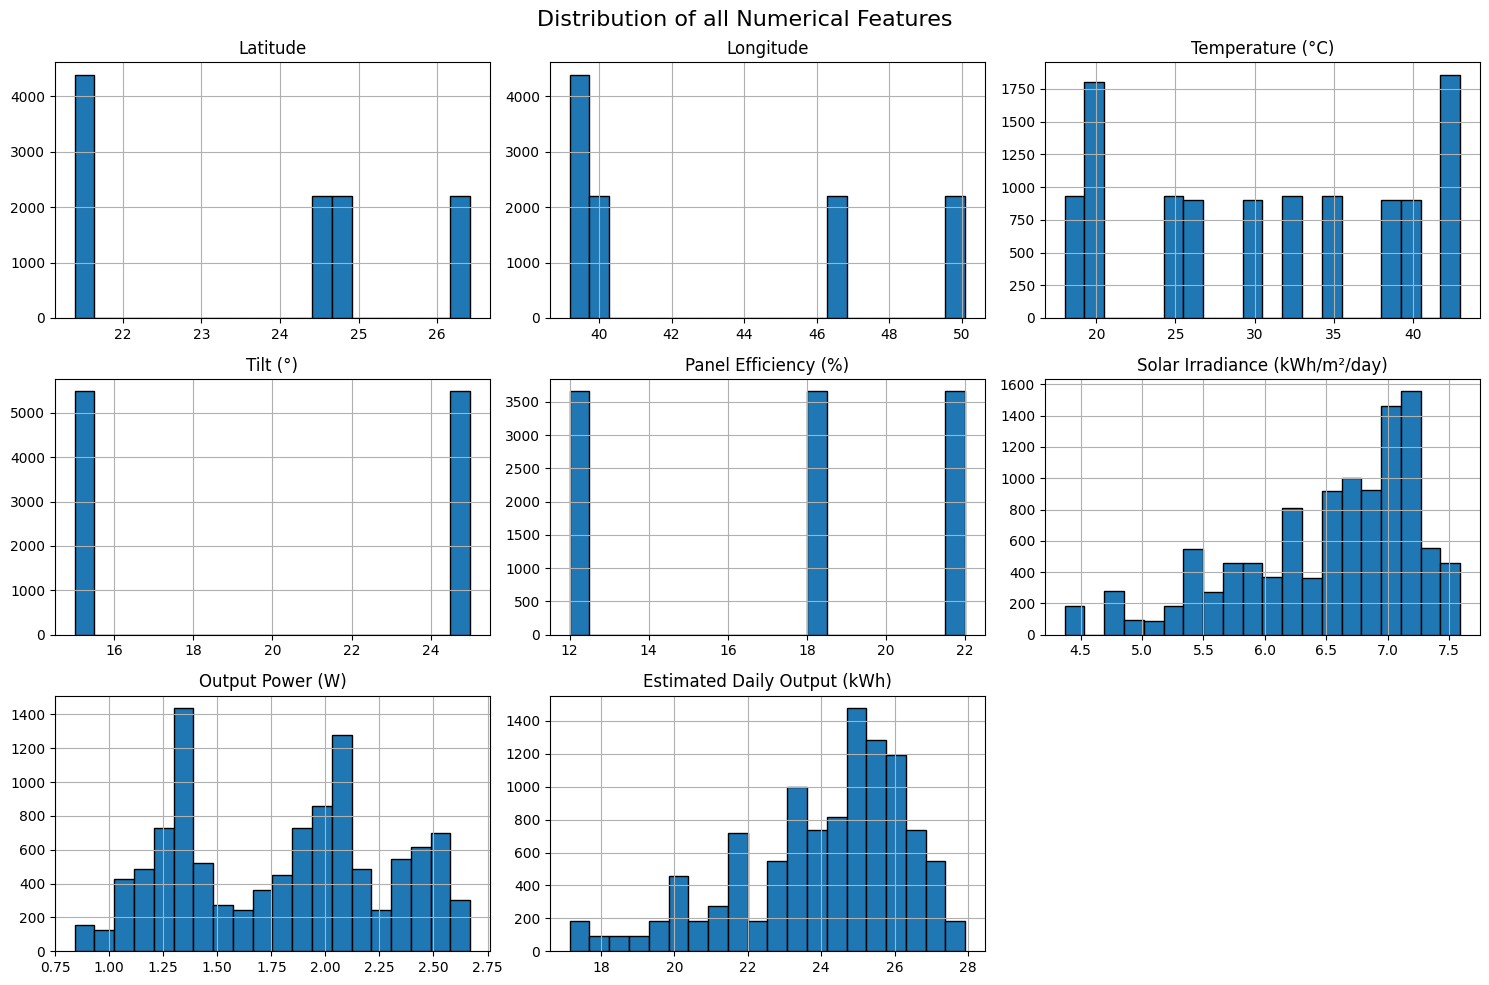

In [51]:
#edgecolor="black" to show each columns clearly
# show the Histogram for all numerical features
df_solar[numerical_features].hist(figsize=(15, 10), bins=20, edgecolor="black")

plt.suptitle("Distribution of all Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [52]:
# show the time period covered by the dataset
print('Start date',df_solar['Date'].min())
print('End date',df_solar['Date'].max())

Start date 1/1/2024
End date 9/9/2024


In [53]:
# Count the City distribution
df_solar["City"].value_counts()

,count
City,
Riyadh,2196
Jeddah,2196
Mecca,2196
Medina,2196
Dammam,2196


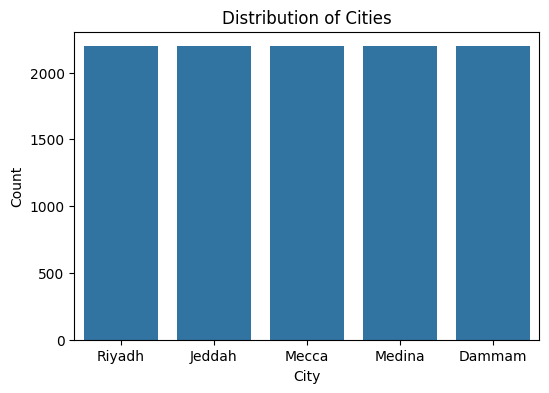

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_solar, x="City")
plt.title("Distribution of Cities")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

In [55]:
# Count the Panel Type distribution
df_solar["Panel Type"].value_counts()

,count
Panel Type,
Monocrystalline,3660
Polycrystalline,3660
Thin-Film,3660


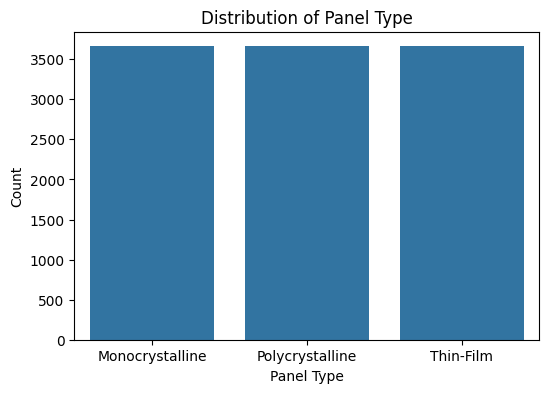

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_solar, x="Panel Type")
plt.title("Distribution of Panel Type")
plt.xlabel("Panel Type")
plt.ylabel("Count")
plt.show()

In [57]:
# Count the Mount Type distribution
df_solar["Mount Type"].value_counts()

,count
Mount Type,
Rooftop,5490
Ground,5490


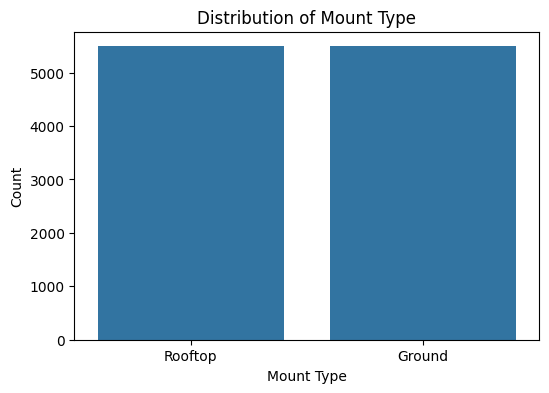

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_solar, x="Mount Type")
plt.title("Distribution of Mount Type")
plt.xlabel("Mount Type")
plt.ylabel("Count")
plt.show()

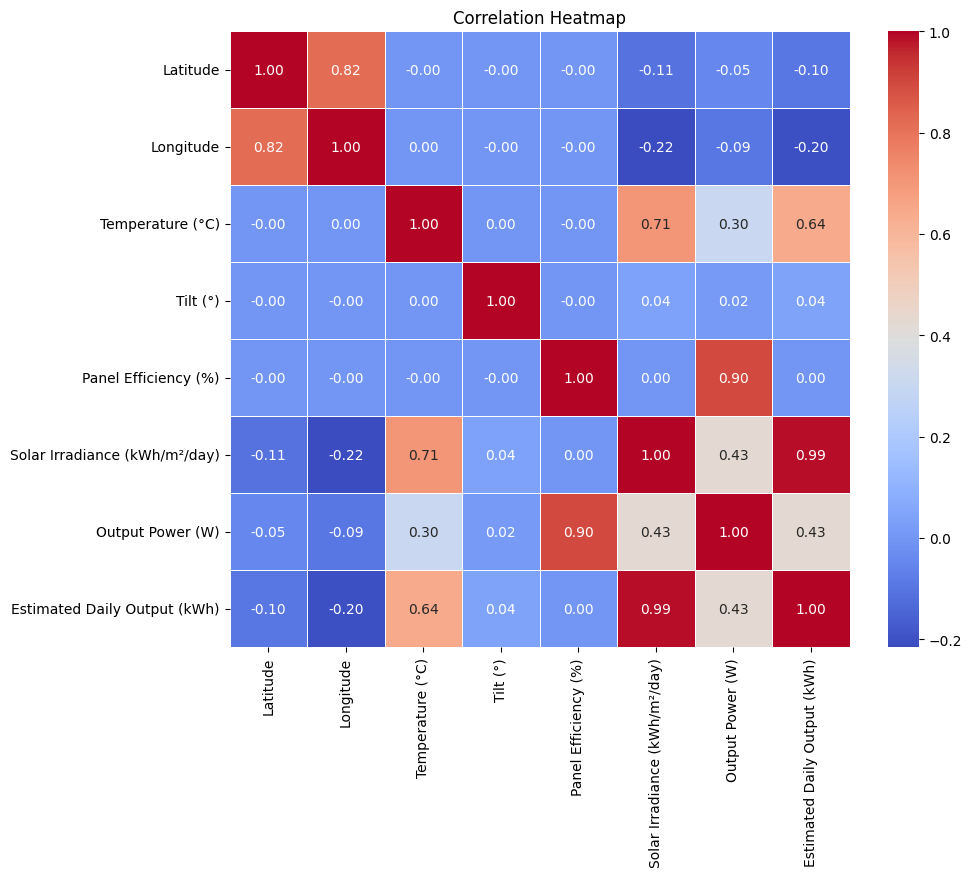

In [59]:
# Correlation between numerical features
correlation_matrix = df_solar.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap( correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

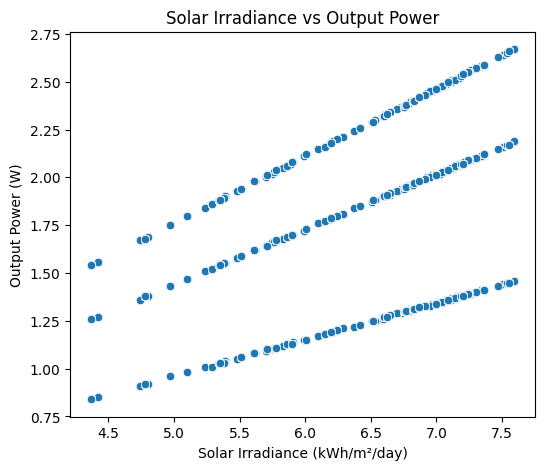

In [60]:
#Solar Irradiance vs Output Power
plt.figure(figsize=(6,5))
sns.scatterplot( data=df_solar, x="Solar Irradiance (kWh/m²/day)", y="Output Power (W)")
plt.title("Solar Irradiance vs Output Power")
plt.xlabel("Solar Irradiance (kWh/m²/day)")
plt.ylabel("Output Power (W)")
plt.show()

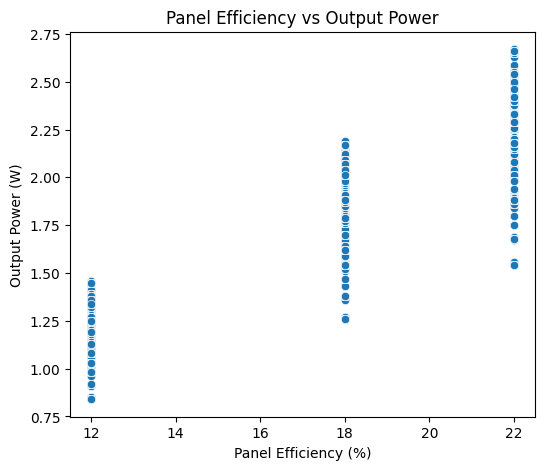

In [61]:
#Panel Efficiency vs Output Power
plt.figure(figsize=(6,5))
sns.scatterplot( data=df_solar, x="Panel Efficiency (%)", y="Output Power (W)")
plt.title("Panel Efficiency vs Output Power")
plt.xlabel("Panel Efficiency (%)")
plt.ylabel("Output Power (W)")
plt.show()

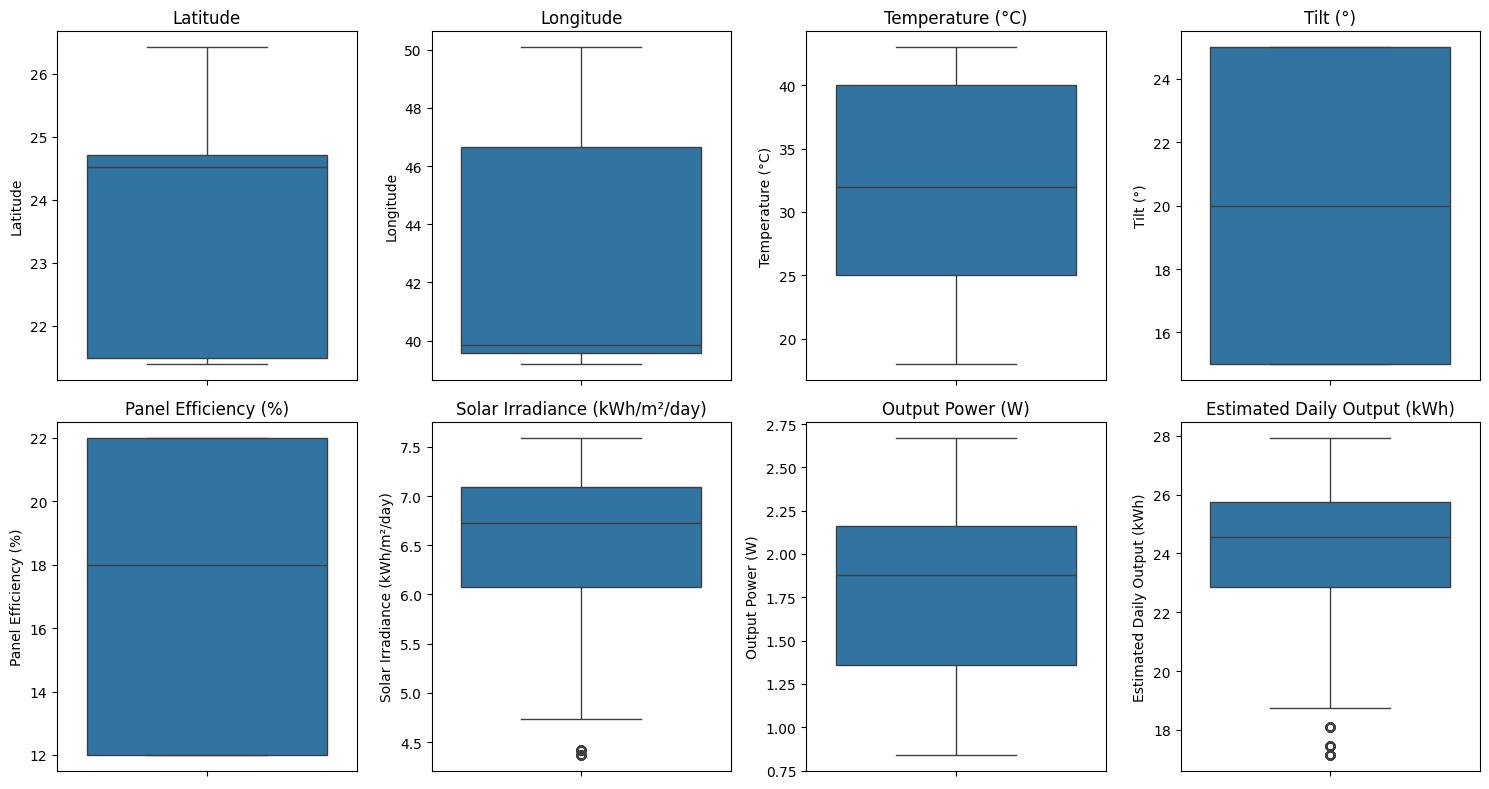

In [62]:
# boxplot for معرفة توزيع the numbers outliers in all numerical features
n_cols = 4
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(y=df_solar[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 3.3.4 Cleaning and Validation




In [63]:
# count the number of outliers numerical features before Outlier Handling
for col in numerical_features:
    Q1 = df_solar[col].quantile(0.25)
    Q3 = df_solar[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_solar[col] < lower) | (df_solar[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Latitude: 0 outliers
Longitude: 0 outliers
Temperature (°C): 0 outliers
Tilt (°): 0 outliers
Panel Efficiency (%): 0 outliers
Solar Irradiance (kWh/m²/day): 186 outliers
Output Power (W): 0 outliers
Estimated Daily Output (kWh): 276 outliers


In [64]:
# Convert Date column to datetime
df_solar["Date"] = pd.to_datetime(df_solar["Date"])

In [65]:
print("KSA Solar Power Dataset shape after clean:", df_solar.shape)
df_solar.head()

KSA Solar Power Dataset shape after clean: (10980, 13)


,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh)
0,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Rooftop,25,22,5.39,1.90,21.06
1,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Rooftop,25,18,5.39,1.55,21.06
2,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Thin-Film,Rooftop,25,12,5.39,1.04,21.06
3,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Ground,15,22,4.97,1.75,19.47
4,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Ground,15,18,4.97,1.43,19.47



The solar dataset was reviewed and all important panel features were kept.
During model building, any variable that could directly affect the target value was removed to prevent data leakage and improve the reliability of the model.

# 4. Data Preparation and Integration

## 4.1 Calendar Feature Engineering



In [66]:
# Extract date features
df_solar["Month"] = df_solar["Date"].dt.month
df_solar["Day"] = df_solar["Date"].dt.day
df_solar["Weekday"] = df_solar["Date"].dt.day_name()

In [67]:
# Add day-of-year cyclical features (captures seasonality across the year)
df_solar["DayOfYear"] = df_solar["Date"].dt.dayofyear
df_solar["doy_sin"] = np.sin(2 * np.pi * df_solar["DayOfYear"] / 365)
df_solar["doy_cos"] = np.cos(2 * np.pi * df_solar["DayOfYear"] / 365)

In [68]:
# to see the columns after Convert and Extract features (new date features)
df_solar[["Date", "Month", "Day", "Weekday"]].head()

,Date,Month,Day,Weekday
0,2024-01-01,1,1,Monday
1,2024-01-01,1,1,Monday
2,2024-01-01,1,1,Monday
3,2024-01-01,1,1,Monday
4,2024-01-01,1,1,Monday


In [69]:
# Check the new columns
df_solar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10980 entries, 0 to 10979
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           10980 non-null  datetime64[ns]
 1   City                           10980 non-null  object        
 2   Latitude                       10980 non-null  float64       
 3   Longitude                      10980 non-null  float64       
 4   Temperature (°C)               10980 non-null  int64         
 5   Weather                        10980 non-null  object        
 6   Panel Type                     10980 non-null  object        
 7   Mount Type                     10980 non-null  object        
 8   Tilt (°)                       10980 non-null  int64         
 9   Panel Efficiency (%)           10980 non-null  int64         
 10  Solar Irradiance (kWh/m²/day)  10980 non-null  float64       
 11  Output Power (W


The original date was kept for data alignment, and new features such as Month, Day, and Weekday were created to help the models learn seasonal and time-related patterns.

## 4.2 Data Integration

All three dataset sources are joined at the daily city level to create one modeling dataset.


### 4.2.1 Merge the Datasets

The merge key is `Date + City`, using the solar table as the left-side reference.


In [70]:
df_weather["Date"] = pd.to_datetime(df_weather["Date"])
df_air["Date"] = pd.to_datetime(df_air["Date"])
df_solar["Date"] = pd.to_datetime(df_solar["Date"])

In [71]:
df_solar_merged = pd.merge(
    df_solar,
    df_weather,
    on=["Date", "City"],
    how="left"
)

In [72]:
df_solar_merged = pd.merge(
   df_solar_merged,
    df_air,
   on=["Date","City"],
   how="left"
)

In [73]:
df_solar_merged.head()

,Date,City,Latitude_x,Longitude_x,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),...,sunshine_duration,Latitude,Longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,sulphur_dioxide,us_aqi
0,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Rooftop,25,22,...,36000.0,24.7136,46.6753,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
1,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Rooftop,25,18,...,36000.0,24.7136,46.6753,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
2,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Thin-Film,Rooftop,25,12,...,36000.0,24.7136,46.6753,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
3,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Ground,15,22,...,36000.0,24.7136,46.6753,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
4,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Ground,15,18,...,36000.0,24.7136,46.6753,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25


In [74]:
df_solar_merged = df_solar_merged.drop(
    columns=["Latitude_y", "Longitude_y"]
)

In [75]:
df_clean_solar = df_solar_merged.rename(
    columns={
        "Latitude_x" :"Latitude",
        "Longitude_x":"Longitude"
    }
)

In [76]:
# The two joins bring in a few identically named columns; keep the first occurrence only
df_clean_solar = df_clean_solar.loc[:, ~df_clean_solar.columns.duplicated()]
print("Shape after removing duplicated columns:", df_clean_solar.shape)


Shape after removing duplicated columns: (10980, 35)


### 4.2.2 Check Merge Quality

check whether weather or AQI information was lost during
the joins.


In [77]:
# Check that the merge did not introduce missing weather or air-quality values
print("Rows missing weather data after merge:", df_clean_solar["temperature_2m_mean"].isna().sum())
print("Rows missing air quality data after merge:", df_clean_solar["us_aqi"].isna().sum())

Rows missing weather data after merge: 0
Rows missing air quality data after merge: 0


### 4.2.3 Final Integrated Dataset Overview


In [78]:
print("Final integrated dataset shape:", df_clean_solar.shape)
df_clean_solar.head()

Final integrated dataset shape: (10980, 35)


,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),...,precipitation_sum,shortwave_radiation_sum,sunshine_duration,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,sulphur_dioxide,us_aqi
0,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Rooftop,25,22,...,0.0,14.37,36000.0,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
1,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Rooftop,25,18,...,0.0,14.37,36000.0,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
2,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Thin-Film,Rooftop,25,12,...,0.0,14.37,36000.0,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
3,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Ground,15,22,...,0.0,14.37,36000.0,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25
4,2024-01-01,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Ground,15,18,...,0.0,14.37,36000.0,200.8625,38.658333,263.125,37.154167,46.208333,55.258333,115.25



The integrated table contains **10,980 rows and 32 columns**, with no missing weather or air-quality values introduced by the merge.


# 5. Model 1A — Full-Feature Solar Output Regression

**Question:** Can we accurately predict the daily solar energy output using weather, location, solar panel information, and seasonal features?

**Target:** `Estimated Daily Output (kWh)`

**Models:** We used **Linear Regression** as a simple baseline model because it is easy to understand and explain.
We also used **Random Forest** to capture more complex relationships between the features.
A random train-test split was used to ensure that data from different months appeared in both sets, and
cross-validation was applied to check that the results were consistent and reliable.

## 5.1 Target Exploration

Before building the models, we explored the target variable to understand its distribution, check for possible outliers, and see how it is related to weather and air quality features.

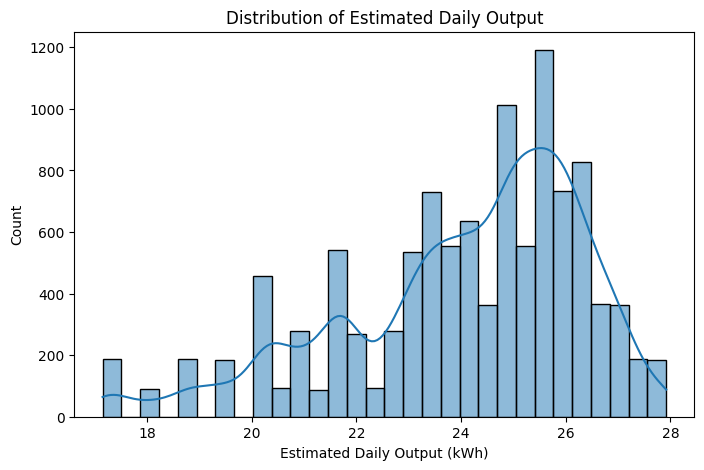

In [79]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean_solar,
    x="Estimated Daily Output (kWh)",
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Daily Output")
plt.show()

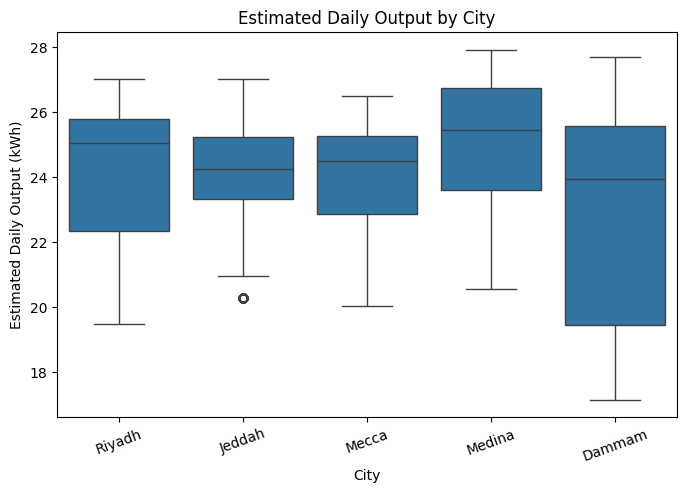

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean_solar,
    x="City",
    y="Estimated Daily Output (kWh)"
)

plt.title("Estimated Daily Output by City")
plt.xticks(rotation=20)
plt.show()

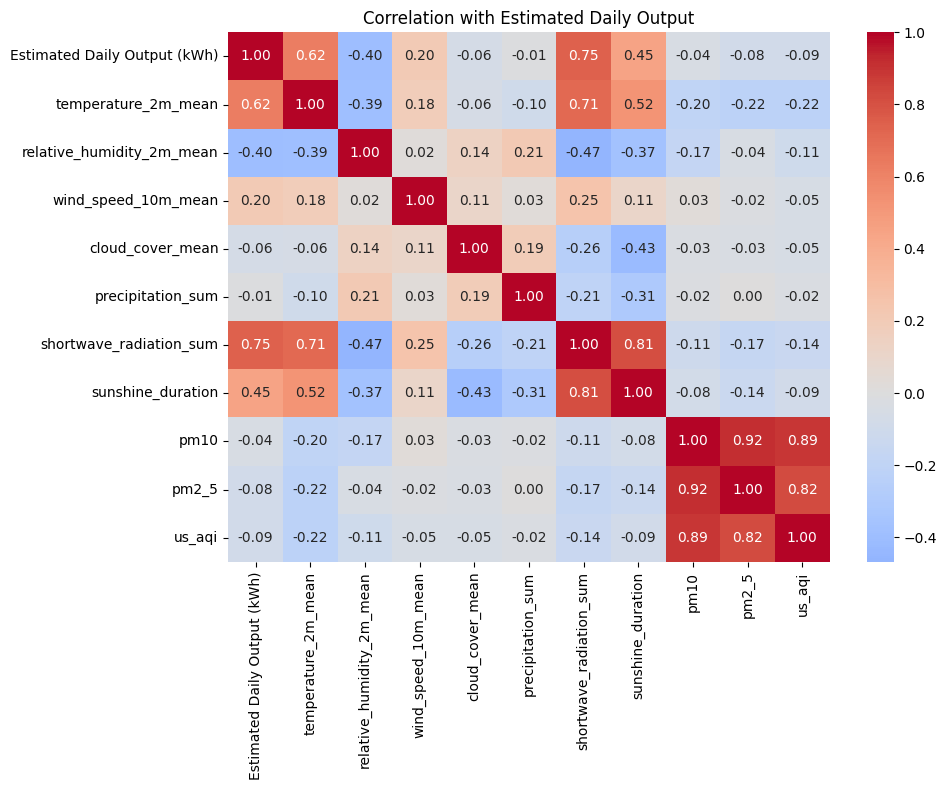

In [81]:
corr_cols = [
    "Estimated Daily Output (kWh)",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "wind_speed_10m_mean",
    "cloud_cover_mean",
    "precipitation_sum",
    "shortwave_radiation_sum",
    "sunshine_duration",
    "pm10",
    "pm2_5",
    "us_aqi"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean_solar[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation with Estimated Daily Output")
plt.tight_layout()
plt.show()

In [82]:
# Which panel type delivered the highest average output?
df_clean_solar.groupby("Panel Type")["Estimated Daily Output (kWh)"].mean().sort_values(ascending=False)

,Estimated Daily Output (kWh)
Panel Type,
Monocrystalline,24.042257
Polycrystalline,24.042257
Thin-Film,24.042257


In [83]:
# Efficiency differs between panel types but the recorded output is very close -
# the output column is largely driven by irradiance and season.
df_clean_solar[[
    "Panel Type",
    "Panel Efficiency (%)",
    "Estimated Daily Output (kWh)"
]].head(10)


,Panel Type,Panel Efficiency (%),Estimated Daily Output (kWh)
0,Monocrystalline,22,21.06
1,Polycrystalline,18,21.06
2,Thin-Film,12,21.06
3,Monocrystalline,22,19.47
4,Polycrystalline,18,19.47
5,Thin-Film,12,19.47
6,Monocrystalline,22,21.06
7,Polycrystalline,18,21.06
8,Thin-Film,12,21.06
9,Monocrystalline,22,19.47


## 5.2 Categorical Encoding

machine learning models can not work directly with text values, we converted the categorical features (City, Panel Type, Mount Type, and Weekday) into dummy variables before training the models.

In [84]:
# Check the values in categorical columns
print(df_clean_solar["City"].unique())
print(df_clean_solar["Weather"].unique())
print(df_clean_solar["Panel Type"].unique())
print(df_clean_solar["Mount Type"].unique())
print(df_clean_solar["Weekday"].unique())

['Riyadh' 'Jeddah' 'Mecca' 'Medina' 'Dammam']
['few clouds' 'scattered clouds' 'sunny' 'clear sky']
['Monocrystalline' 'Polycrystalline' 'Thin-Film']
['Rooftop' 'Ground']
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']


In [85]:
df_model = pd.get_dummies(
    df_clean_solar,
    columns=["City", "Panel Type", "Mount Type", "Weekday"],
    drop_first=True,
    dtype=int
)
df_model.head()

,Date,Latitude,Longitude,Temperature (°C),Weather,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh),...,City_Riyadh,Panel Type_Polycrystalline,Panel Type_Thin-Film,Mount Type_Rooftop,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday
0,2024-01-01,24.7136,46.6753,18,few clouds,25,22,5.39,1.90,21.06,...,1,0,0,1,1,0,0,0,0,0
1,2024-01-01,24.7136,46.6753,18,few clouds,25,18,5.39,1.55,21.06,...,1,1,0,1,1,0,0,0,0,0
2,2024-01-01,24.7136,46.6753,18,few clouds,25,12,5.39,1.04,21.06,...,1,0,1,1,1,0,0,0,0,0
3,2024-01-01,24.7136,46.6753,18,few clouds,15,22,4.97,1.75,19.47,...,1,0,0,0,1,0,0,0,0,0
4,2024-01-01,24.7136,46.6753,18,few clouds,15,18,4.97,1.43,19.47,...,1,1,0,0,1,0,0,0,0,0


In [86]:
dup_cols = df_model.columns[df_model.columns.duplicated()]
print("Duplicated column names:", dup_cols.tolist())

Duplicated column names: []


Features that directly represented the target or contained information about the actual solar output were removed before training to avoid data leakage and ensure fair model performance.

## 5.3 Feature and Target Selection


In [87]:
# نستبعد كل عمود جاي مباشرة من بيانات الشمس نفسها ومتغيّر بالوقت
# عشان ما يصير داتا ليكيج، نعتمد على الطقس + جودة الهواء + الموقع + التوقيت الموسمي
exclude_cols = [
    "Date", "DayOfYear",
    "Estimated Daily Output (kWh)", "Solar Irradiance (kWh/m²/day)",
    "Output Power (W)", "Temperature (°C)",
    "Month", "Day" , # doy_sin / doy_cos استبدلتها ب
    "Weather"

]

feature_cols = [c for c in df_model.columns if c not in exclude_cols]

X = df_model[feature_cols]
y = df_model["Estimated Daily Output (kWh)"]

print("number of features used", len(feature_cols))
print(feature_cols)


number of features used 35
['Latitude', 'Longitude', 'Tilt (°)', 'Panel Efficiency (%)', 'doy_sin', 'doy_cos', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'wind_speed_10m_mean', 'wind_direction_10m_dominant', 'cloud_cover_mean', 'precipitation_sum', 'shortwave_radiation_sum', 'sunshine_duration', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'us_aqi', 'City_Jeddah', 'City_Mecca', 'City_Medina', 'City_Riyadh', 'Panel Type_Polycrystalline', 'Panel Type_Thin-Film', 'Mount Type_Rooftop', 'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday', 'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday']


In [88]:
print(X.dtypes.value_counts())

int64      18
float64    17
Name: count, dtype: int64


## 5.4 Train/Test Split


In [89]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# بدال التقسيم بالزمن نقسم عشوائي عشان اضمن امثل كل الشهور في التدريب فا نستخدم تقسيم عشوائي
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (8784, 35) | Test shape: (2196, 35)


## 5.5 Linear Regression


In [90]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("--- Linear Regression ---")
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R²:", r2_score(y_test, pred_lr))


--- Linear Regression ---
MAE: 0.9237391929193064
RMSE: 1.1456029813153357
R²: 0.763087975212223


## 5.6 Random Forest Regression


In [91]:
rf_solar = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)
rf_solar.fit(X_train, y_train)
pred_rf = rf_solar.predict(X_test)

print("--- Random Forest Regressor ---")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2:", r2_score(y_test, pred_rf))


--- Random Forest Regressor ---
MAE: 0.2839654752158286
RMSE: 0.4106392585540781
R2: 0.9695603420245477


## 5.7 Evaluation and Generalization Check




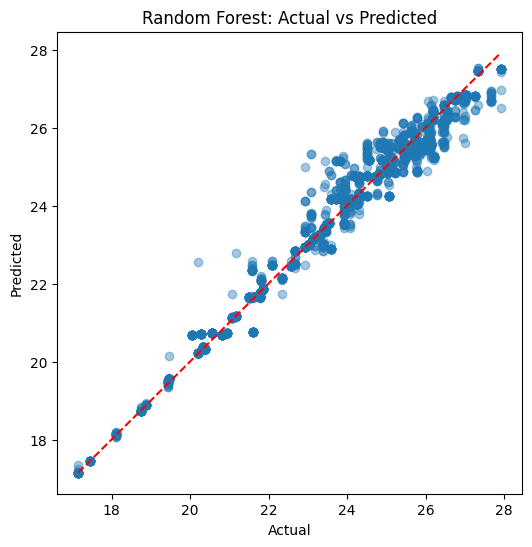

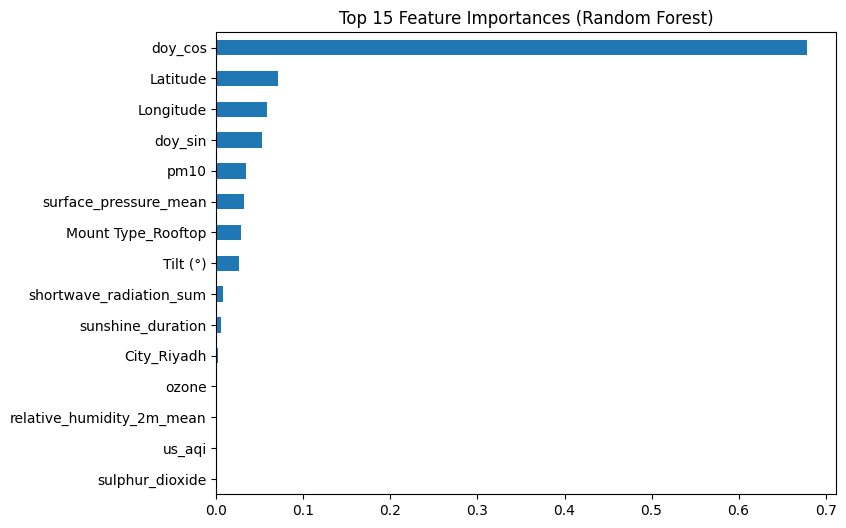

In [92]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

feat_importance = pd.Series(rf_solar.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
feat_importance.plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


In [93]:
pred_lr_train = lr.predict(X_train)
pred_rf_train = rf_solar.predict(X_train)

def print_metrics(name, y_true_train, pred_train, y_true_test, pred_test):
    mae_train = mean_absolute_error(y_true_train, pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_true_train, pred_train))
    r2_train = r2_score(y_true_train, pred_train)

    mae_test = mean_absolute_error(y_true_test, pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_true_test, pred_test))
    r2_test = r2_score(y_true_test, pred_test)

    print(f"--- {name} ---")
    print(f"{'Metric':<10} {'Train':>12} {'Test':>12} {'Gap':>12}")
    print(f"{'MAE':<10} {mae_train:>12.4f} {mae_test:>12.4f} {mae_test - mae_train:>12.4f}")
    print(f"{'RMSE':<10} {rmse_train:>12.4f} {rmse_test:>12.4f} {rmse_test - rmse_train:>12.4f}")
    print(f"{'R²':<10} {r2_train:>12.4f} {r2_test:>12.4f} {r2_train - r2_test:>12.4f}")

print_metrics("Linear Regression", y_train, pred_lr_train, y_test, pred_lr)
print_metrics("Random Forest", y_train, pred_rf_train, y_test, pred_rf)


--- Linear Regression ---
Metric            Train         Test          Gap
MAE              0.9501       0.9237      -0.0264
RMSE             1.1775       1.1456      -0.0319
R²               0.7415       0.7631      -0.0216
--- Random Forest ---
Metric            Train         Test          Gap
MAE              0.2847       0.2840      -0.0007
RMSE             0.4136       0.4106      -0.0029
R²               0.9681       0.9696      -0.0014


The evaluation results were stored in variables so we could use them later in the final comparison table without running the models again.

In [94]:
model1A_lr_mae = mean_absolute_error(y_test, pred_lr)
model1A_lr_r2 = r2_score(y_test, pred_lr)
model1A_rf_mae = mean_absolute_error(y_test, pred_rf)
model1A_rf_r2 = r2_score(y_test, pred_rf)

## 5.8 Five-Fold Cross-Validation



In [95]:
# Cross-validation confirms the model is stable across different partitions
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_rf_cv = -cross_val_score(rf_solar, X, y, cv=kf, scoring="neg_mean_absolute_error")
r2_rf_cv = cross_val_score(rf_solar, X, y, cv=kf, scoring="r2")

print("--- Random Forest (5-Fold Cross-Validation) ---")
print(f"Mean MAE: {mae_rf_cv.mean():.4f}")
print(f"Mean R²: {r2_rf_cv.mean():.4f}")

--- Random Forest (5-Fold Cross-Validation) ---
Mean MAE: 0.2947
Mean R²: 0.9657


## 5.9 Reusable Prediction Function

We created a prediction function that takes the user's inputs (date, location, and solar panel settings), converts them into the same feature format used during training, and then predicts the expected daily solar energy output. It also compares the predicted value with the highest historical output to show the system's expected performance.


In [96]:
max_output_per_group = df_clean_solar.groupby(
    ["City", "Panel Type", "Mount Type"]
)["Estimated Daily Output (kWh)"].max().reset_index()
max_output_per_group.rename(columns={"Estimated Daily Output (kWh)": "Max_Output"}, inplace=True)

In [97]:
def predict_output(date_str, city, panel_type, mount_type,
                    temp, humidity, pressure, wind_speed, wind_dir,
                    cloud_cover, precip, shortwave_rad, sunshine,
                    pm10, pm2_5, co, no2, ozone_val, so2, aqi,
                    latitude, longitude, tilt=25, efficiency=20):

    input_date = pd.to_datetime(date_str)
    doy = input_date.dayofyear

    values = {
        "Latitude": latitude, "Longitude": longitude,
        "Tilt (°)": tilt, "Panel Efficiency (%)": efficiency,
        "temperature_2m_mean": temp, "relative_humidity_2m_mean": humidity,
        "surface_pressure_mean": pressure, "wind_speed_10m_mean": wind_speed,
        "wind_direction_10m_dominant": wind_dir, "cloud_cover_mean": cloud_cover,
        "precipitation_sum": precip, "shortwave_radiation_sum": shortwave_rad,
        "sunshine_duration": sunshine, "pm10": pm10, "pm2_5": pm2_5,
        "carbon_monoxide": co, "nitrogen_dioxide": no2, "ozone": ozone_val,
        "sulphur_dioxide": so2, "us_aqi": aqi,
        "doy_sin": np.sin(2 * np.pi * doy / 365),
        "doy_cos": np.cos(2 * np.pi * doy / 365),
    }

    active_dummies = [f"City_{city}", f"Panel Type_{panel_type}",
                       f"Mount Type_{mount_type}",
                       f"Weekday_{input_date.day_name()}"]

    new_input = pd.DataFrame([{**{c: 0 for c in feature_cols}, **values,
                                **{c: 1 for c in active_dummies if c in feature_cols}}])[feature_cols]

    prediction = rf_solar.predict(new_input)[0]

    max_val = max_output_per_group[
        (max_output_per_group["City"] == city) &
        (max_output_per_group["Panel Type"] == panel_type) &
        (max_output_per_group["Mount Type"] == mount_type)
    ]["Max_Output"].values[0]
    efficiency_percentage = (prediction / max_val) * 100

    print(f" {input_date.date()} | {city} | {panel_type} | {mount_type}")
    print(f"Prediction: {prediction:.2f} kWh")
    print(f"Efficiency Percentage {efficiency_percentage:.1f}%")
    return prediction, efficiency_percentage

In [98]:
predict_output(
    date_str="2025-06-15", city="Jeddah", panel_type="Monocrystalline", mount_type="Rooftop",
    temp=33.2, humidity=45, pressure=1001.8, wind_speed=10.3, wind_dir=324,
    cloud_cover=15, precip=0, shortwave_rad=26.33, sunshine=44474.81,
    pm10=25, pm2_5=14, co=200, no2=25, ozone_val=90, so2=25, aqi=68,
    latitude=21.54, longitude=39.17
)

 2025-06-15 | Jeddah | Monocrystalline | Rooftop
Prediction: 24.19 kWh
Efficiency Percentage 89.5%


(np.float64(24.185609990267615), np.float64(89.51002957167881))

## 5.10 External Validation with Open-Meteo Data

To test the model on real-world data, we used weather and air quality information from Open-Meteo for Jeddah on 15 June 2025. These values were passed to the prediction function to evaluate how the model performs on data that was not used during training.

In [99]:
import requests

# اجيب بيانات الطقس الحقيقيه من Open-Meteo لجدة بتاريخ 2025-06-15
url_weather = "https://archive-api.open-meteo.com/v1/archive"
params_weather = {
    "latitude": 21.54,
    "longitude": 39.17,
    "start_date": "2025-06-15",
    "end_date": "2025-06-15",
    "daily": "temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,"
             "wind_speed_10m_mean,wind_direction_10m_dominant,cloud_cover_mean,"
             "precipitation_sum,shortwave_radiation_sum,sunshine_duration",
    "timezone": "auto"
}
response_weather = requests.get(url_weather, params=params_weather)
weather_data = response_weather.json()
print("real weather data")
print(weather_data["daily"])


real weather data
{'time': ['2025-06-15'], 'temperature_2m_mean': [33.2], 'relative_humidity_2m_mean': [45], 'surface_pressure_mean': [1001.8], 'wind_speed_10m_mean': [10.3], 'wind_direction_10m_dominant': [324], 'cloud_cover_mean': [15], 'precipitation_sum': [0.0], 'shortwave_radiation_sum': [26.33], 'sunshine_duration': [44474.81]}


In [100]:
url_air = "https://air-quality-api.open-meteo.com/v1/air-quality"
params_air = {
    "latitude": 21.54,
    "longitude": 39.17,
    "start_date": "2025-06-15",
    "end_date": "2025-06-15",
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone,sulphur_dioxide,us_aqi",
    "timezone": "auto"
}
response_air = requests.get(url_air, params=params_air)
air_data = response_air.json()
print(air_data)

{'latitude': 21.5, 'longitude': 39.199997, 'generationtime_ms': 0.6885528564453125, 'utc_offset_seconds': 10800, 'timezone': 'Asia/Riyadh', 'timezone_abbreviation': 'GMT+3', 'elevation': 9.0, 'hourly_units': {'time': 'iso8601', 'pm10': 'μg/m³', 'pm2_5': 'μg/m³', 'carbon_monoxide': 'μg/m³', 'nitrogen_dioxide': 'μg/m³', 'ozone': 'μg/m³', 'sulphur_dioxide': 'μg/m³', 'us_aqi': 'USAQI'}, 'hourly': {'time': ['2025-06-15T00:00', '2025-06-15T01:00', '2025-06-15T02:00', '2025-06-15T03:00', '2025-06-15T04:00', '2025-06-15T05:00', '2025-06-15T06:00', '2025-06-15T07:00', '2025-06-15T08:00', '2025-06-15T09:00', '2025-06-15T10:00', '2025-06-15T11:00', '2025-06-15T12:00', '2025-06-15T13:00', '2025-06-15T14:00', '2025-06-15T15:00', '2025-06-15T16:00', '2025-06-15T17:00', '2025-06-15T18:00', '2025-06-15T19:00', '2025-06-15T20:00', '2025-06-15T21:00', '2025-06-15T22:00', '2025-06-15T23:00'], 'pm10': [32.9, 32.0, 30.0, 17.6, 17.3, 17.2, 18.6, 20.2, 21.9, 24.1, 26.3, 26.4, 23.9, 20.1, 17.0, 9.1, 8.5, 8.3,

In [101]:
import numpy as np

h = air_data["hourly"]
pm10_avg = np.mean(h["pm10"])
pm2_5_avg = np.mean(h["pm2_5"])
co_avg = np.mean(h["carbon_monoxide"])
no2_avg = np.mean(h["nitrogen_dioxide"])
ozone_avg = np.mean(h["ozone"])
so2_avg = np.mean(h["sulphur_dioxide"])
aqi_avg = np.mean(h["us_aqi"])

print(f"pm10={pm10_avg:.1f}, pm2.5={pm2_5_avg:.1f}, CO={co_avg:.1f}, NO2={no2_avg:.1f}, O3={ozone_avg:.1f}, SO2={so2_avg:.1f}, AQI={aqi_avg:.1f}")

pm10=20.3, pm2.5=13.3, CO=201.6, NO2=24.5, O3=89.8, SO2=23.6, AQI=67.7


In [102]:
d = weather_data["daily"]

result_real = predict_output(
    date_str="2025-06-15", city="Jeddah", panel_type="Monocrystalline", mount_type="Rooftop",
    temp=d["temperature_2m_mean"][0],
    humidity=d["relative_humidity_2m_mean"][0],
    pressure=d["surface_pressure_mean"][0],
    wind_speed=d["wind_speed_10m_mean"][0],
    wind_dir=d["wind_direction_10m_dominant"][0],
    cloud_cover=d["cloud_cover_mean"][0],
    precip=d["precipitation_sum"][0],
    shortwave_rad=d["shortwave_radiation_sum"][0],
    sunshine=d["sunshine_duration"][0],
    pm10=pm10_avg, pm2_5=pm2_5_avg, co=co_avg,
    no2=no2_avg, ozone_val=ozone_avg,
    so2=so2_avg, aqi=aqi_avg,
    latitude=21.54, longitude=39.17
)

 2025-06-15 | Jeddah | Monocrystalline | Rooftop
Prediction: 24.19 kWh
Efficiency Percentage 89.5%


In [103]:
cloud_val = d["cloud_cover_mean"][0]

if cloud_val < 10:
    weather_desc = "clear sky"
elif cloud_val < 30:
    weather_desc = "few clouds"
elif cloud_val < 60:
    weather_desc = "scattered clouds"
else:
    weather_desc = "overcast"

print(f"Actual cloud percentage: {cloud_val:.1f}% -> Inferred weather: {weather_desc}")


Actual cloud percentage: 15.0% -> Inferred weather: few clouds


## 5.11 Decision — Model 1A

Based on the evaluation results, **Random Forest** was selected as the best model for predicting daily solar energy output.

It achieved better performance than Linear Regression, with a **lower MAE (0.284 kWh)** and a **higher R² (0.970)**, which means the model was able to predict the daily solar output more accurately.

The cross-validation results also showed consistent performance (**Mean MAE = 0.295** and **Mean R² = 0.966**), indicating that the model is stable and generalizes well to unseen data.

Finally, we tested the model using real weather data from **Jeddah (15 June 2025)**, it predicted **24.19 kWh**, which is about **89.5%** of the historical maximum output for the same panel configuration



# 6. Model 1B — Domain-Informed Solar Regression


**Question:** Can we achieve similar prediction accuracy using fewer features?

In Model 1B, we used the same pipeline as Model 1A but removed only **Tilt (°)** and **Mount Type**.
The goal was to check whether a simpler feature set, based on domain knowledge, could still produce accurate predictions while reducing model complexity.

The idea behind this model is that the daily solar output mainly depends on:

**Estimated Daily Output (kWh) = Solar Irradiance × Panel Efficiency × Panel Type × Seasonal & Location Factors**

This experiment helps us understand whether these core features are enough without relying on tilt angle or mount type.

## 6.1 Reuse the Prepared Modeling Table

Instead of preparing the data again, we reused the encoded **df_model** from Model 1A. This ensures that the only difference between Model 1A and Model 1B is the selected features, making the comparison fair.

## 6.2 Reduced Feature Selection


In [104]:
# Same feature list as Model 1A, but without Tilt, Mount Type, and the
# cyclical date features (doy_sin / doy_cos)
features_1B = [c for c in feature_cols if c not in ["Tilt (°)", "doy_sin", "doy_cos"] and not c.startswith("Mount Type_")]
X1B = df_model[features_1B]
y1B = df_model["Estimated Daily Output (kWh)"]

print("number of features used in Model 1B:", len(features_1B))
print(features_1B)

number of features used in Model 1B: 31
['Latitude', 'Longitude', 'Panel Efficiency (%)', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'wind_speed_10m_mean', 'wind_direction_10m_dominant', 'cloud_cover_mean', 'precipitation_sum', 'shortwave_radiation_sum', 'sunshine_duration', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'us_aqi', 'City_Jeddah', 'City_Mecca', 'City_Medina', 'City_Riyadh', 'Panel Type_Polycrystalline', 'Panel Type_Thin-Film', 'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday', 'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday']


## 6.3  Train/Test Split


In [105]:
# Same random_state as Model 1A so the split lines up on the same rows
X1B_tr, X1B_te, y1B_tr, y1B_te = train_test_split(
    X1B, y1B, test_size=0.2, random_state=42
)

print("Train shape:", X1B_tr.shape, "| Test shape:", X1B_te.shape)

Train shape: (8784, 31) | Test shape: (2196, 31)


## 6.4 Linear Regression


In [106]:
lr_1B = LinearRegression()
lr_1B.fit(X1B_tr, y1B_tr)
pred_lr_1B = lr_1B.predict(X1B_te)

print("--- Model 1B: Linear Regression ---")
print("MAE:", mean_absolute_error(y1B_te, pred_lr_1B))
print("RMSE:", np.sqrt(mean_squared_error(y1B_te, pred_lr_1B)))
print("R²:", r2_score(y1B_te, pred_lr_1B))

--- Model 1B: Linear Regression ---
MAE: 0.9532312501282827
RMSE: 1.184327789236499
R²: 0.7468005991717779


## 6.5 Random Forest Regression


In [107]:
rf_1B = RandomForestRegressor( n_estimators=300, max_depth=6, min_samples_leaf=10, random_state=42)

rf_1B.fit(X1B_tr, y1B_tr)
pred_rf_1B = rf_1B.predict(X1B_te)

print("--- Model 1B: Random Forest Regressor ---")
print("MAE:", mean_absolute_error(y1B_te, pred_rf_1B))
print("RMSE:", np.sqrt(mean_squared_error(y1B_te, pred_rf_1B)))
print("R²:", r2_score(y1B_te, pred_rf_1B))

--- Model 1B: Random Forest Regressor ---
MAE: 0.6863151459915748
RMSE: 0.8428651261629277
R²: 0.8717566056600125


## 6.6 Evaluation


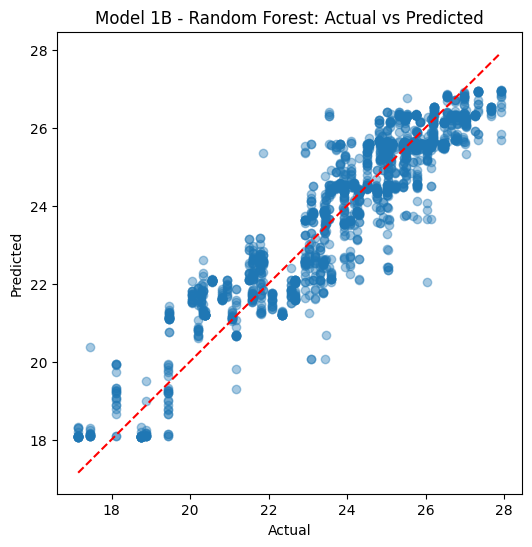

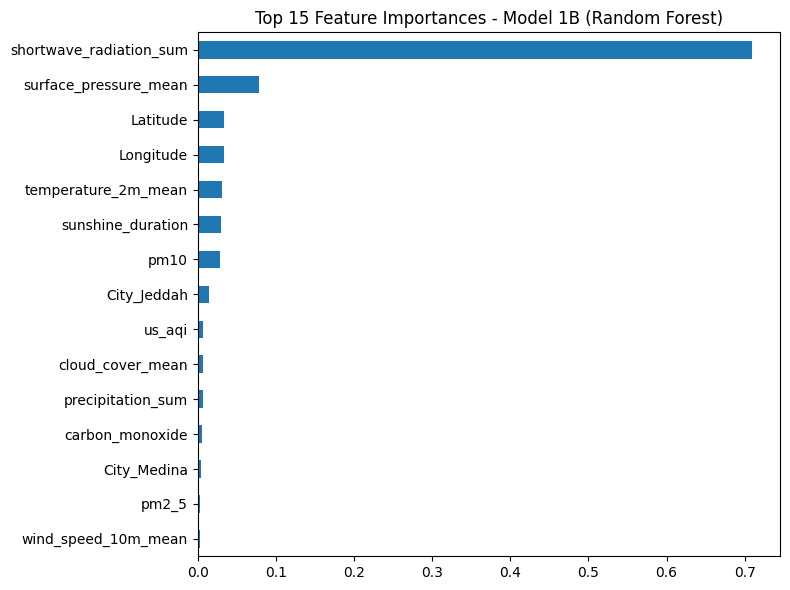

In [108]:
plt.figure(figsize=(6,6))
plt.scatter(y1B_te, pred_rf_1B, alpha=0.4)
plt.plot([y1B_te.min(), y1B_te.max()], [y1B_te.min(), y1B_te.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model 1B - Random Forest: Actual vs Predicted")
plt.show()

feat_importance_1B = pd.Series(rf_1B.feature_importances_, index=features_1B).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
feat_importance_1B.plot(kind="barh")
plt.title("Top 15 Feature Importances - Model 1B (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [109]:
# Save Model 1B metrics into their own variables (same reasoning as Model 1A, Section 5.6)
model1B_lr_mae = mean_absolute_error(y1B_te, pred_lr_1B)
model1B_lr_r2 = r2_score(y1B_te, pred_lr_1B)
model1B_rf_mae = mean_absolute_error(y1B_te, pred_rf_1B)
model1B_rf_r2 = r2_score(y1B_te, pred_rf_1B)

In [110]:
#أي نوع لوح أعطى أعلى إنتاج؟
df_clean_solar.groupby("Panel Type")["Estimated Daily Output (kWh)"].mean().sort_values(ascending=False)

,Estimated Daily Output (kWh)
Panel Type,
Monocrystalline,24.042257
Polycrystalline,24.042257
Thin-Film,24.042257


In [111]:
#أي نوع لوح أعطى أعلى إنتاج؟
df_clean_solar[[
    "Panel Type",
    "Panel Efficiency (%)",
    "Estimated Daily Output (kWh)"
]].head(10)
#الإنتاج (Output) نفسه رغم أن الكفاءة مختلفة.

,Panel Type,Panel Efficiency (%),Estimated Daily Output (kWh)
0,Monocrystalline,22,21.06
1,Polycrystalline,18,21.06
2,Thin-Film,12,21.06
3,Monocrystalline,22,19.47
4,Polycrystalline,18,19.47
5,Thin-Film,12,19.47
6,Monocrystalline,22,21.06
7,Polycrystalline,18,21.06
8,Thin-Film,12,21.06
9,Monocrystalline,22,19.47


## 6.7 Five-Fold Cross-Validation


In [112]:
mae_rf_1B_cv = -cross_val_score(rf_1B, X1B, y1B, cv=kf, scoring="neg_mean_absolute_error")
r2_rf_1B_cv = cross_val_score(rf_1B, X1B, y1B, cv=kf, scoring="r2")

print("--- Model 1B: Random Forest (5-Fold Cross-Validation) ---")
print(f"Mean MAE: {mae_rf_1B_cv.mean():.4f}")
print(f"Mean R²: {r2_rf_1B_cv.mean():.4f}")

--- Model 1B: Random Forest (5-Fold Cross-Validation) ---
Mean MAE: 0.6918
Mean R²: 0.8643


## 6.8 External Validation on the Same Real-World Day


In [113]:
doy_real = pd.to_datetime("2025-06-15").dayofyear

values_1B = {
    "Latitude": 21.54, "Longitude": 39.17,
    "Panel Efficiency (%)": 20,
    "temperature_2m_mean": d["temperature_2m_mean"][0],
    "relative_humidity_2m_mean": d["relative_humidity_2m_mean"][0],
    "surface_pressure_mean": d["surface_pressure_mean"][0],
    "wind_speed_10m_mean": d["wind_speed_10m_mean"][0],
    "wind_direction_10m_dominant": d["wind_direction_10m_dominant"][0],
    "cloud_cover_mean": d["cloud_cover_mean"][0],
    "precipitation_sum": d["precipitation_sum"][0],
    "shortwave_radiation_sum": d["shortwave_radiation_sum"][0],
    "sunshine_duration": d["sunshine_duration"][0],
    "pm10": pm10_avg, "pm2_5": pm2_5_avg, "carbon_monoxide": co_avg,
    "nitrogen_dioxide": no2_avg, "ozone": ozone_avg,
    "sulphur_dioxide": so2_avg, "us_aqi": aqi_avg,
    "doy_sin": np.sin(2 * np.pi * doy_real / 365),
    "doy_cos": np.cos(2 * np.pi * doy_real / 365),
}

active_dummies_1B = ["City_Jeddah", "Panel Type_Monocrystalline",
                      "Weekday_" + pd.to_datetime("2025-06-15").day_name()]

new_input_1B = pd.DataFrame([{**{c: 0 for c in features_1B}, **values_1B,
                               **{c: 1 for c in active_dummies_1B if c in features_1B}}])[features_1B]

prediction_1B = rf_1B.predict(new_input_1B)[0]

print(f"Model 1B prediction for the same real-world day: {prediction_1B:.2f} kWh")
print(f"Model 1A prediction (Section 5.9) was: {result_real[0]:.2f} kWh")


Model 1B prediction for the same real-world day: 24.62 kWh
Model 1A prediction (Section 5.9) was: 24.19 kWh


## 6.9 Decision — Model 1B

The results show that **Random Forest** still performed well after removing **Tilt** and **Mount Type**, but its performance was slightly lower than Model 1A.

The model achieved **MAE = 0.686 kWh** and **R² = 0.872**, while Model 1A achieved **MAE = 0.284 kWh** and **R² = 0.970**.

Cross-validation also showed stable performance (**Mean MAE = 0.692** and **Mean R² = 0.864**).

This experiment shows that using fewer features is possible, but **Tilt** and **Mount Type** still provide useful information for predicting solar energy output.



Therefore, **Model 1A** was selected as the final solar prediction model because it achieved the best overall performance.


# 7. Model 2A — Next-Day AQI Regression

**Question:** Can today's weather and air quality measurements be used to predict tomorrow's Air Quality Index (AQI)?

**Target:** `Next_Day_AQI`

To create the target, we shifted the **US AQI** values by one day for each location (latitude and longitude).
This means the model learns from today's conditions to predict the AQI of the next day.

**Validation:** To simulate a real forecasting scenario, we trained the model using data up to **30 November**, left **1 December** as a gap to avoid data leakage, and used data starting from **2 December** for testing.

## 7.1 Prepare the Air-Quality Modeling Table and Target


In [114]:
# Re-use the already-merged and dummy-encoded dataframe from Model 1A (Section 5.1)
# instead of re-reading it from a separately exported CSV file
air_model = df_model.copy()

In [115]:
# Remove duplicate rows using date and location
air_model=air_model.drop_duplicates(subset=["Date","Latitude","Longitude"])

# Sort the observations chronologically for each location this prepares the data for creating the next-day target

air_model = air_model.sort_values(["Latitude","Longitude","Date"])

print("Air Data Model Shape",air_model.shape)

Air Data Model Shape (1830, 44)


In [116]:
# Creating our target variable based on location and us_aqi it means how is the quality of air

air_model["Next_Day_AQI"]=(air_model.groupby(["Latitude", "Longitude"])["us_aqi"].shift(-1))

air_model = air_model.dropna(subset=["Next_Day_AQI"])

In [117]:
air_model["Month"] = air_model["Date"].dt.month
air_model["DayOfYear"]=air_model["Date"].dt.dayofyear
air_model[["Date","Month","DayOfYear"]].head()

,Date,Month,DayOfYear
4392,2024-01-01,1,1
4398,2024-01-02,1,2
4404,2024-01-03,1,3
4410,2024-01-04,1,4
4416,2024-01-05,1,5


## 7.2 Explore the Next-Day AQI Target




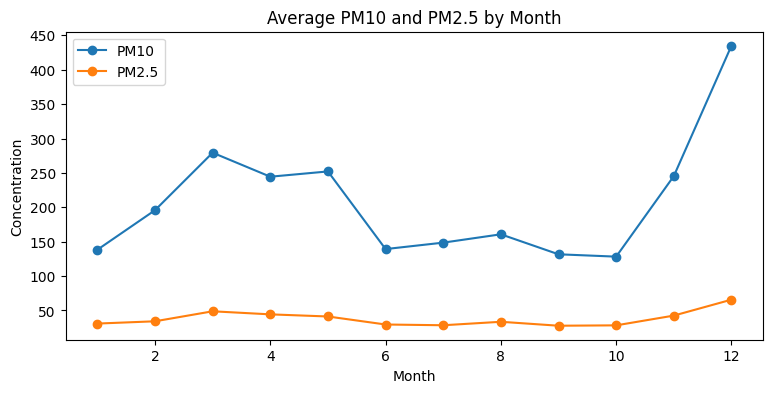

In [118]:
# Calculate average PM10 and PM2.5 for each month
monthly_pollution = air_model.groupby("Month")[["pm10", "pm2_5"]].mean().reset_index()

plt.figure(figsize=(9, 4))
plt.plot(monthly_pollution["Month"], monthly_pollution["pm10"], marker="o", label="PM10")
plt.plot(monthly_pollution["Month"], monthly_pollution["pm2_5"], marker="o", label="PM2.5")
plt.title("Average PM10 and PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Concentration")
plt.legend()
plt.show()

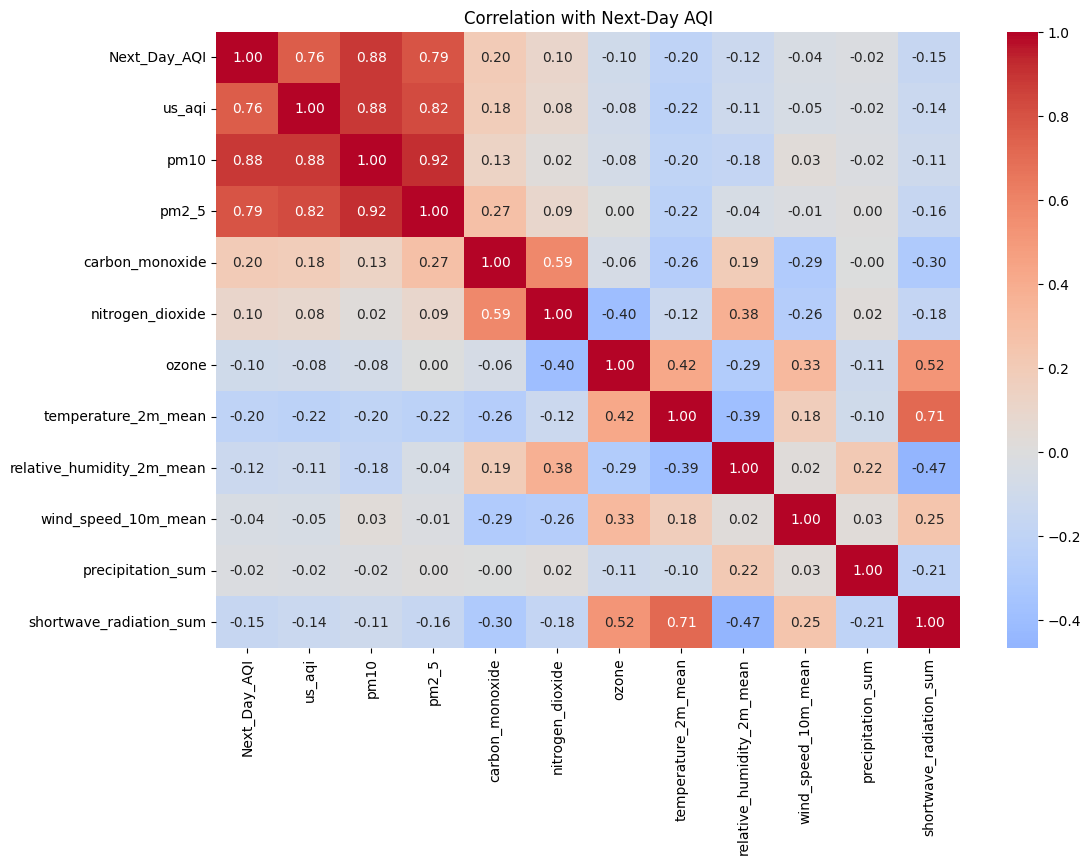

In [119]:
correlation_columns = [
    "Next_Day_AQI", "us_aqi", "pm10", "pm2_5", "carbon_monoxide",
    "nitrogen_dioxide", "ozone", "temperature_2m_mean",
    "relative_humidity_2m_mean", "wind_speed_10m_mean",
    "precipitation_sum", "shortwave_radiation_sum"
]

correlation = air_model[correlation_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with Next-Day AQI")
plt.show()

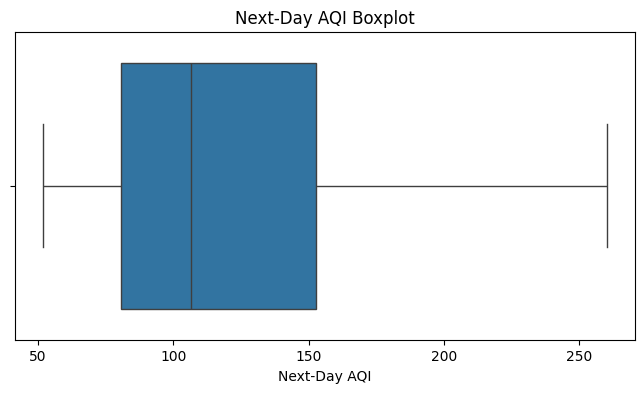

In [120]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=air_model, x="Next_Day_AQI", showfliers=False)
plt.title("Next-Day AQI Boxplot")
plt.xlabel("Next-Day AQI")
plt.show()

## 7.3 Feature and Target Selection




In [121]:
features = [
    # Weather
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "wind_speed_10m_mean",
    "wind_direction_10m_dominant",
    "cloud_cover_mean",
    "precipitation_sum",
    "shortwave_radiation_sum",
    "sunshine_duration",

    # Air quality today
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "ozone",
    "sulphur_dioxide",
    "us_aqi",

    # Date
    "Month",
    "DayOfYear",

    # City
    "City_Jeddah",
    "City_Mecca",
    "City_Medina",
    "City_Riyadh"
]

X=air_model[features]
y=air_model["Next_Day_AQI"]

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (1825, 22)
y shape: (1825,)


In [122]:
# Remove duplicate rows using date and location
air_model = air_model.drop_duplicates(subset=["Date","Latitude","Longitude"])

# Sort the observations chronologically for each location
air_model = air_model.sort_values(["Latitude","Longitude","Date"])

print("Air Data Model Shape", air_model.shape)

# Creating our target variable based on location and us_aqi
air_model["Next_Day_AQI"] = (
    air_model.groupby(["Latitude", "Longitude"])["us_aqi"].shift(-1)
)

air_model = air_model.dropna(subset=["Next_Day_AQI"])

Air Data Model Shape (1825, 45)


## 7.4 Chronological Train/Test Split




In [123]:
# Training until November 30
train_data = air_model[
    air_model["Date"] <= "2024-11-30"
].copy()

# Leave December 1 as a time gap
# Testing starts from December 2
test_data = air_model[
    air_model["Date"] >= "2024-12-02"
].copy()

# Create X and y
X_train = train_data[features]
y_train = train_data["Next_Day_AQI"]

X_test = test_data[features]
y_test = test_data["Next_Day_AQI"]

## 7.5 Baseline and Linear Regression Training



In [124]:
# Baseline: today's AQI predicts tomorrow's AQI
baseline_pred = test_data["us_aqi"]

print("Baseline Results")
print("MAE:", round(mean_absolute_error(y_test, baseline_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline_pred)), 2))
print("R²:", round(r2_score(y_test, baseline_pred), 3))

# Linear Regression
linear_model = LinearRegression().fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

print("\nLinear Regression Results")
print("MAE:", round(mean_absolute_error(y_test, linear_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, linear_pred)), 2))
print("R²:", round(r2_score(y_test, linear_pred), 3))
print("PR-AUC:", round(average_precision_score((y_test > 200).astype(int), linear_pred), 3))

Baseline Results
MAE: 172.63
RMSE: 410.86
R²: 0.493

Linear Regression Results
MAE: 119.47
RMSE: 272.99
R²: 0.776
PR-AUC: 0.962


## 7.6 Evaluation and Explainability




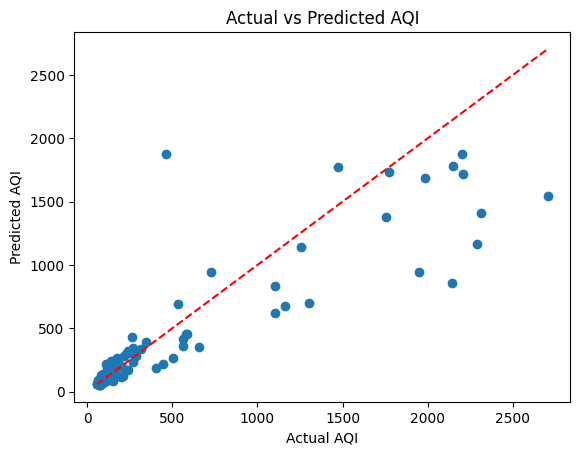

In [125]:
plt.scatter(y_test, linear_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

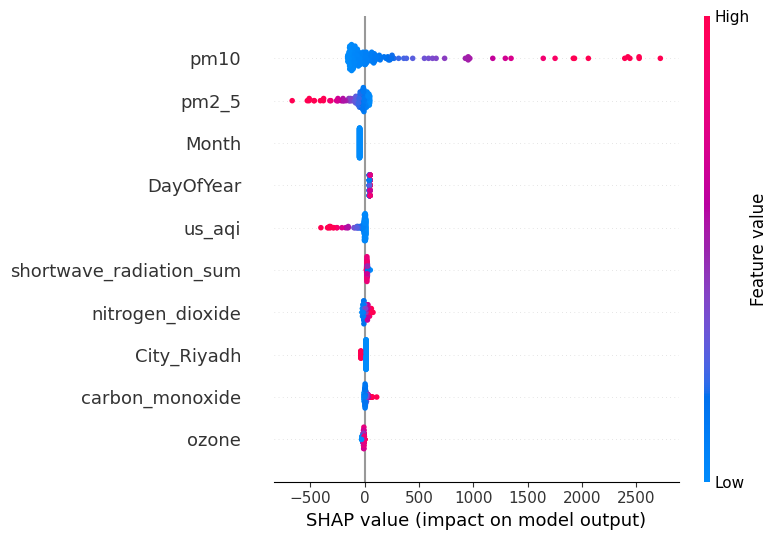

In [126]:
import shap

# Calculate SHAP values
explainer = shap.Explainer(linear_model, X_train)
shap_values = explainer(X_test)

# Show the 10 most important features
shap.summary_plot(shap_values.values,X_test,max_display=10)

The evaluation results were stored in variables so we could use them later in the final comparison table without running the models again.

In [127]:
model2A_baseline_mae = mean_absolute_error(y_test, baseline_pred)
model2A_baseline_r2 = r2_score(y_test, baseline_pred)
model2A_linear_mae = mean_absolute_error(y_test, linear_pred)
model2A_linear_r2 = r2_score(y_test, linear_pred)

## 7.7 Decision — Model 2A

The results show that **Linear Regression** performed much better than the baseline model for predicting the next day's AQI.

The **MAE** decreased from **172.63** to **119.47**, which means the prediction error was reduced.
At the same time, the **R²** increased from **0.493** to **0.776**, showing that the model was able to explain more of the variation in AQI values.

The model also achieved a **PR-AUC of 0.962**, indicating that it performed well in identifying high-risk AQI days.

From the prediction plot, we can see that the model predicted most AQI values reasonably well.
However, the errors became larger when the AQI reached extremely high values.

Some `us_aqi` values in this dataset are above **2,700**, which is much higher than the official US AQI scale (maximum of 500).
These extreme cases are more difficult for the model to predict and increase the overall regression error.

Finally, the SHAP analysis showed that **PM10** was the most important feature affecting the model's predictions, while the remaining weather and air-quality features had a smaller impact.

# 8. Model 2B — Next-Day AQI Risk Classification

**Question:** Can today's weather and air quality measurements be used to predict tomorrow's AQI risk level?

**Target:** `Next_Day_AQI_Class`

Instead of predicting the exact AQI value, we converted the next day's AQI into three risk categories.
This makes the results easier to understand and more useful for decision making.

| Class | AQI Range | Meaning |
|--------|----------:|---------|
| Acceptable | 0–100 | Lower operational risk |
| Elevated Risk | 101–200 | Increased attention required |
| Severe Risk | Above 200 | High-priority alert |

**Validation:** We reused the same chronological train-test split from Model 2A. The model was trained using data up to **30 November**, **1 December** was left as a gap to prevent data leakage, and testing started from **2 December**.

## 8.1 Prepare the Classification Target



In [128]:
# Create three AQI risk classes
bins = [0, 100, 200, 3000]
class_names = ["Acceptable", "Elevated Risk", "Severe Risk"]

y_train_class = pd.cut(y_train, bins=bins, labels=[0, 1, 2]).astype(int)

y_test_class = pd.cut(y_test, bins=bins, labels=[0, 1, 2]).astype(int)

## 8.1 Model Training



In [129]:
xg = XGBClassifier(n_estimators=300, max_depth=6 ,learning_rate=0.05, random_state=42 )

xg.fit(X_train, y_train_class)

rf_aqi = RandomForestClassifier(random_state=42).fit(X_train, y_train_class)

## 8.2 Evaluation



In [130]:
xgp = xg.predict(X_test)
rfp = rf_aqi.predict(X_test)
print("--- XGBoost ---")
print("Accuracy:",round(accuracy_score(y_test_class, xgp), 3))
print(" F1:",round(f1_score(y_test_class, xgp,average="macro"), 3))

print(classification_report(
    y_test_class, xgp,
    labels=[0, 1, 2],
    target_names=class_names,
))

print("--- Random Forest ---")
print("Accuracy:",round(accuracy_score(y_test_class, rfp), 3))
print(" F1:",round(f1_score(y_test_class, rfp,average="macro"), 3))

print(classification_report(
    y_test_class, rfp,
    labels=[0, 1, 2],
    target_names=class_names,
))

--- XGBoost ---
Accuracy: 0.914
 F1: 0.916
               precision    recall  f1-score   support

   Acceptable       0.90      0.95      0.92        37
Elevated Risk       0.89      0.92      0.90        61
  Severe Risk       0.97      0.88      0.93        42

     accuracy                           0.91       140
    macro avg       0.92      0.91      0.92       140
 weighted avg       0.92      0.91      0.91       140

--- Random Forest ---
Accuracy: 0.886
 F1: 0.887
               precision    recall  f1-score   support

   Acceptable       0.81      0.92      0.86        37
Elevated Risk       0.87      0.89      0.88        61
  Severe Risk       1.00      0.86      0.92        42

     accuracy                           0.89       140
    macro avg       0.89      0.89      0.89       140
 weighted avg       0.89      0.89      0.89       140



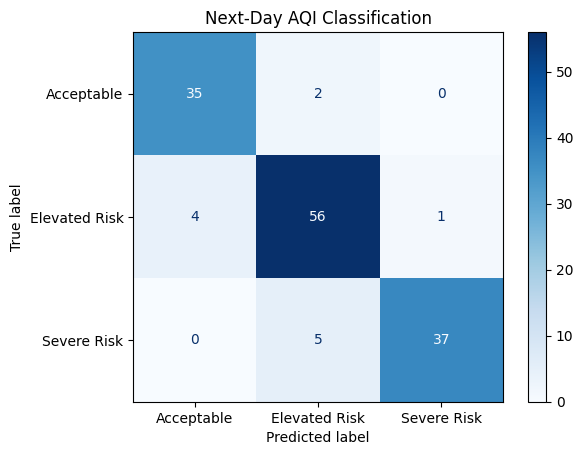

In [131]:
ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    xgp,
    labels=[0, 1, 2],
    display_labels=class_names,
    cmap="Blues"
)

plt.title("Next-Day AQI Classification")
plt.show()

The evaluation results were stored in variables so we could use them later in the final comparison table without running the models again.

In [132]:
model2B_xgb_accuracy = accuracy_score(y_test_class, xgp)
model2B_xgb_f1 = f1_score(y_test_class, xgp, average="macro")
model2B_rf_accuracy = accuracy_score(y_test_class, rfp)
model2B_rf_f1 = f1_score(y_test_class, rfp, average="macro")

## 8.3 Decision — Model 2B
Based on the evaluation results, **XGBoost** was selected as the best model for predicting the next day's AQI risk level.

It achieved **91.4% accuracy** and a **Macro F1-score of 91.6%**, outperforming Random Forest, which achieved **88.6% accuracy** and a **Macro F1-score of 88.7%**.

Another important result is that XGBoost achieved **88% recall** for the **Severe Risk** class. This means it correctly identified most high-risk pollution days. It also did not classify any **Severe Risk** case as **Acceptable**, making it a more reliable model for detecting critical air quality conditions.


# 9. Model 3 — Does Air Quality Add Predictive Value to Solar Output?


**Question:** Does adding air quality features improve solar energy prediction compared to using weather data only?

**Target:** `Solar Output Category (Low, Medium, High)`

To answer this question, we built two **Random Forest** classification models.

The first model uses only weather features, while the second model uses the same weather features plus air quality measurements.

**Validation:** Both models used the same dataset, the same train-test split, and the same algorithm.
The only difference was the input features, allowing us to fairly measure the effect of adding air quality data.


In [133]:
# We reuse df_model (already merged: solar + weather + air quality)
# and create a simple 3-level output category as the target for this model
model3_data = df_model.copy()

# Split Estimated Daily Output into 3 equal-sized groups: Low, Medium, High
model3_data["Output_Category"] = pd.qcut(
    model3_data["Estimated Daily Output (kWh)"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(model3_data["Output_Category"].value_counts())

Output_Category
Low       3735
Medium    3666
High      3579
Name: count, dtype: int64


## 9.1 Target and Feature Sets


In [134]:
# Weather-only feature set (same weather columns used in Model 1A/1B)
weather_only_features = [
    "temperature_2m_mean", "relative_humidity_2m_mean", "surface_pressure_mean",
    "wind_speed_10m_mean", "wind_direction_10m_dominant", "cloud_cover_mean",
    "precipitation_sum", "shortwave_radiation_sum", "sunshine_duration"
]

# Weather + air quality feature set
weather_and_air_features = weather_only_features + [
    "pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "ozone", "sulphur_dioxide", "us_aqi"
]

X_weather_only = model3_data[weather_only_features]
X_weather_and_air = model3_data[weather_and_air_features]
y_output_category = model3_data["Output_Category"]

print("Weather-only feature count:", len(weather_only_features))
print("Weather + air quality feature count:", len(weather_and_air_features))


Weather-only feature count: 9
Weather + air quality feature count: 16


## 9.2  Train/Test Split


In [135]:
X_wo_train, X_wo_test, y_train_cat, y_test_cat = train_test_split(
    X_weather_only, y_output_category, test_size=0.2, random_state=42
)

X_wa_train, X_wa_test, _, _ = train_test_split(
    X_weather_and_air, y_output_category, test_size=0.2, random_state=42
)

print("Weather-only train/test:", X_wo_train.shape, X_wo_test.shape)
print("Weather+Air train/test:", X_wa_train.shape, X_wa_test.shape)

Weather-only train/test: (8784, 9) (2196, 9)
Weather+Air train/test: (8784, 16) (2196, 16)


## 9.3 Train the Controlled Models


In [136]:
from sklearn.ensemble import RandomForestClassifier

# Model trained on weather features only
rf_weather_only = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf_weather_only.fit(X_wo_train, y_train_cat)
pred_weather_only = rf_weather_only.predict(X_wo_test)

# Model trained on weather + air quality features
rf_weather_and_air = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf_weather_and_air.fit(X_wa_train, y_train_cat)
pred_weather_and_air = rf_weather_and_air.predict(X_wa_test)

## 9.4 Evaluation


In [137]:
print("--- Weather Only ---")
print("Accuracy:", round(accuracy_score(y_test_cat, pred_weather_only), 3))
print("F1 (macro):", round(f1_score(y_test_cat, pred_weather_only, average="macro"), 3))
print(classification_report(y_test_cat, pred_weather_only))

print("\n--- Weather + Air Quality ---")
print("Accuracy:", round(accuracy_score(y_test_cat, pred_weather_and_air), 3))
print("F1 (macro):", round(f1_score(y_test_cat, pred_weather_and_air, average="macro"), 3))
print(classification_report(y_test_cat, pred_weather_and_air))

--- Weather Only ---
Accuracy: 0.804
F1 (macro): 0.798
              precision    recall  f1-score   support

        High       0.76      0.81      0.79       707
         Low       0.87      0.94      0.91       767
      Medium       0.76      0.65      0.70       722

    accuracy                           0.80      2196
   macro avg       0.80      0.80      0.80      2196
weighted avg       0.80      0.80      0.80      2196


--- Weather + Air Quality ---
Accuracy: 0.81
F1 (macro): 0.802
              precision    recall  f1-score   support

        High       0.76      0.88      0.81       707
         Low       0.88      0.93      0.91       767
      Medium       0.78      0.62      0.69       722

    accuracy                           0.81      2196
   macro avg       0.81      0.81      0.80      2196
weighted avg       0.81      0.81      0.80      2196



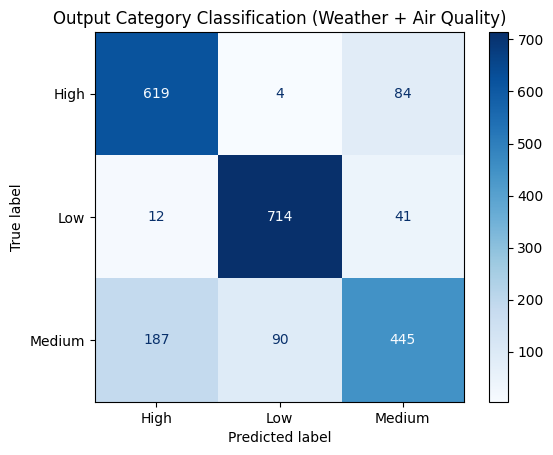

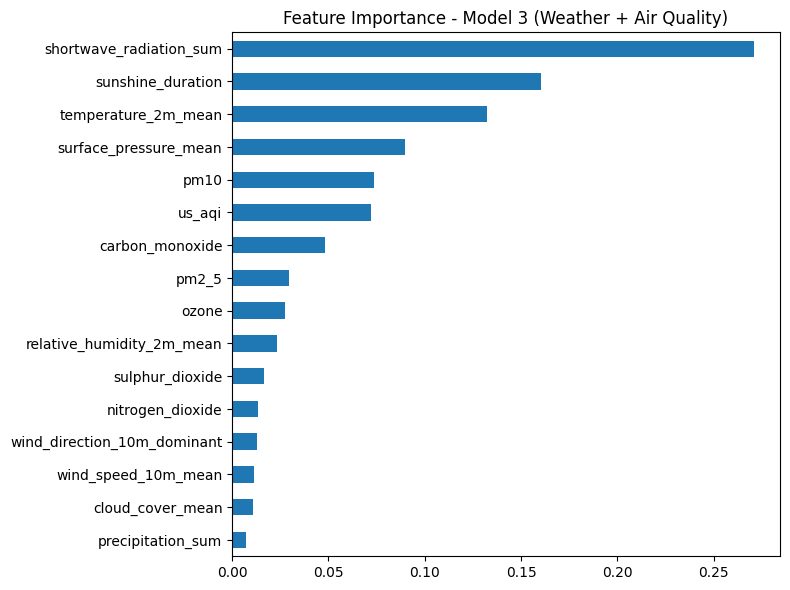

In [138]:
ConfusionMatrixDisplay.from_predictions(
    y_test_cat,
    pred_weather_and_air,
    cmap="Blues"
)
plt.title("Output Category Classification (Weather + Air Quality)")
plt.show()

feat_importance_m3 = pd.Series(
    rf_weather_and_air.feature_importances_, index=weather_and_air_features
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_importance_m3.plot(kind="barh")
plt.title("Feature Importance - Model 3 (Weather + Air Quality)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9.5 Decision — Model 3

The results show only a very small difference after adding **air quality features** to the model.

The **weather-only model** achieved **80.4% accuracy** and a **Macro F1-score of 79.8%**.
After adding air quality data, the performance increased slightly to **81.0% accuracy** and a **Macro F1-score of 80.2%**.

This **0.6% improvement** corresponds to only about **13 samples** out of **2,196** test samples. Such a small difference can happen because of the random train/test split, so it should not be considered strong evidence that air quality improves solar output prediction.

Overall, the results suggest that **weather features remain the main factor** affecting solar output prediction, while air quality adds only a very small amount of additional information in this dataset.

# 10. Final Model Comparison

Since each model solves a different problem, the evaluation metrics should only be compared within the same task.

| Task | Selected Model | Main Result |
|------|----------------|-------------|
| Daily Solar Output Prediction | Model 1A – Random Forest | MAE = **0.284 kWh**, R² = **0.970** |
| Next-Day AQI Prediction | Model 2A – Linear Regression | MAE = **119.47**, R² = **0.776** |
| Next-Day AQI Risk Classification | Model 2B – XGBoost | Accuracy = **91.4%**, Macro F1 = **91.6%** |
| Effect of Air Quality on Solar Prediction | Weather + Air Quality Model | Accuracy improved from **80.4%** to **81.0%** |

Each model was selected based on its performance for its specific task.

Model 1A achieved the best performance for predicting daily solar energy output. Model 2A was the best regression model for predicting the next-day AQI, while Model 2B achieved the highest classification performance for AQI risk levels. Finally, Model 3 showed that adding air-quality features produced only a very small improvement, while weather variables remained the main factor affecting solar energy prediction.



In [139]:
# Final Comparison for model 1 A and model 1 B
final_comparison = pd.DataFrame({
    "Model": ["1A - Linear Regression", "1A - Random Forest", "1B - Linear Regression", "1B - Random Forest"],
    "MAE": [model1A_lr_mae, model1A_rf_mae, model1B_lr_mae, model1B_rf_mae],
    "R2": [model1A_lr_r2, model1A_rf_r2, model1B_lr_r2, model1B_rf_r2],
})
final_comparison


,Model,MAE,R2
0,1A - Linear Regression,0.923739,0.763088
1,1A - Random Forest,0.283965,0.969560
2,1B - Linear Regression,0.953231,0.746801
3,1B - Random Forest,0.686315,0.871757


In [140]:
# Final Comparison for model 2 A and model 2 B
final_comparison2 = pd.DataFrame({
    "Model": [ "2A - Baseline", "2A - Linear Regression", "2B - Random Forest", "2B - XGBoost"],
    "MAE": [ model2A_baseline_mae, model2A_linear_mae, np.nan, np.nan ],
    "R²": [ model2A_baseline_r2, model2A_linear_r2, np.nan, np.nan ],
    "Accuracy": [ np.nan, np.nan, model2B_rf_accuracy, model2B_xgb_accuracy ],
    "F1 Score": [ np.nan, np.nan, model2B_rf_f1, model2B_xgb_f1]
})
final_comparison2

,Model,MAE,R²,Accuracy,F1 Score
0,2A - Baseline,172.634821,0.492963,NaN,NaN
1,2A - Linear Regression,119.471886,0.776152,NaN,NaN
2,2B - Random Forest,NaN,NaN,0.885714,0.887295
3,2B - XGBoost,NaN,NaN,0.914286,0.916426


# 11. RAG-Based Recommendation System

To make the prediction results more useful, we added a simple **RAG (Retrieval-Augmented Generation)** system.
Instead of showing only the predicted values, the system also provides a recommendation supported by real research papers from **arXiv**.

The RAG pipeline has three main steps:

1. **Retrieve:** Search for research papers related to the predicted conditions.
2. **Rank:** Select the most relevant paper using **TF-IDF** and **Cosine Similarity**.
3. **Generate:** Combine the model prediction with the retrieved paper to generate a short recommendation.

This is a simplified version, it demonstrates the basic workflow used in real RAG systems and shows how AI predictions can be supported with scientific evidence.


## 11.1 Retrieval — searching arXiv for relevant scientific papers

In [141]:
import xml.etree.ElementTree as ET

def search_arxiv_papers(query, max_results=5):
    """
    Search arXiv for papers matching the given query.
    Returns a list of dictionaries, each with a paper's title, summary, and link.
    """
    url = "http://export.arxiv.org/api/query"
    params = {
        "search_query": f"all:{query}",
        "start": 0,
        "max_results": max_results
    }

    response = requests.get(url, params=params, timeout=15)
    root = ET.fromstring(response.text)

    # arXiv returns results in the Atom XML namespace
    namespace = {"atom": "http://www.w3.org/2005/Atom"}

    papers = []
    for entry in root.findall("atom:entry", namespace):
        title = entry.find("atom:title", namespace).text.strip().replace("\n", " ")
        summary = entry.find("atom:summary", namespace).text.strip().replace("\n", " ")
        link = entry.find("atom:id", namespace).text.strip()
        papers.append({"title": title, "summary": summary, "link": link})

    return papers


## 11.2 Ranking — picking the most relevant paper with TF-IDF

In [142]:
def rank_papers_by_relevance(query, papers):
    """
    Rank retrieved papers by how similar their summary is to the query,
    using TF-IDF vectors and cosine similarity (same idea as basic search engines).
    Returns the papers sorted from most relevant to least relevant.
    """
    documents = [query] + [paper["summary"] for paper in papers]

    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(documents)

    query_vector = tfidf_matrix[0]
    paper_vectors = tfidf_matrix[1:]

    similarity_scores = cosine_similarity(query_vector, paper_vectors)[0]

    for paper, score in zip(papers, similarity_scores):
        paper["relevance_score"] = score

    ranked_papers = sorted(papers, key=lambda p: p["relevance_score"], reverse=True)
    return ranked_papers


## 11.3 Generation — combining predictions with retrieved evidence

In [143]:
def generate_recommendation(predicted_output_category, predicted_aqi_risk, top_paper):
    """
    Build a short, human-readable recommendation using:
    - the predicted solar output category from Model 3
    - the predicted AQI risk level from Model 2B
    - the most relevant scientific paper found by the retrieval step
    """
    recommendation = []

    recommendation.append(f"Predicted solar output level: {predicted_output_category}")
    recommendation.append(f"Predicted next-day air quality risk: {predicted_aqi_risk}")
    recommendation.append("")

    if predicted_aqi_risk in ["Elevated Risk", "Severe Risk"]:
        recommendation.append(
            "Air quality is expected to be elevated, which may reduce the sunlight reaching solar panels "
            "due to dust and particulate matter in the air. Consider scheduling panel cleaning after this period."
        )
    else:
        recommendation.append(
            "Air quality is expected to stay in an acceptable range, so pollution is not expected to be a major "
            "factor in solar output for this period."
        )

    recommendation.append("")
    recommendation.append("Supporting scientific evidence (retrieved from arXiv):")
    recommendation.append(f"- \"{top_paper['title']}\"")
    recommendation.append(f"  {top_paper['summary'][:300]}...")
    recommendation.append(f"  Link: {top_paper['link']}")

    return "\n".join(recommendation)


## 11.4 Example — running the full Retrieve → Rank → Generate pipeline

In [144]:
# Pick ONE real day from the Model 2B test set and describe that same day with both models.
#df_model and air_model and model3_data share the original index so the row label is enough to line them up
# taking element [0] from two different test sets would have paired unrelated days and cities.
example_idx = test_data.index[0]

# Next-day AQI risk from Model 2B (XGBoost was the preferred classifier)
predicted_aqi_class_number = int(xg.predict(X_test.loc[[example_idx]])[0])
predicted_aqi_risk = class_names[predicted_aqi_class_number]

# Solar output category from Model 3, for the same row
predicted_output_category = rf_weather_and_air.predict(
    model3_data.loc[[example_idx], weather_and_air_features]
)[0]

print("Example date:", air_model.loc[example_idx, "Date"].date())
print("Predicted solar output category:", predicted_output_category)
print("Predicted next-day AQI risk:", predicted_aqi_risk)

# Build a search query based on the predicted conditions
if predicted_aqi_risk in ["Elevated Risk", "Severe Risk"]:
    search_query = "dust particulate matter effect on photovoltaic solar panel efficiency"
else:
    search_query = "weather conditions effect on solar panel energy output"

print("Search query:", search_query)


Example date: 2024-12-02
Predicted solar output category: Low
Predicted next-day AQI risk: Acceptable
Search query: weather conditions effect on solar panel energy output


In [145]:
try:
    retrieved_papers = search_arxiv_papers(search_query, max_results=5)
    ranked_papers = rank_papers_by_relevance(search_query, retrieved_papers)
    top_paper = ranked_papers[0]

    final_recommendation = generate_recommendation(
        predicted_output_category, predicted_aqi_risk, top_paper
    )

    print(final_recommendation)

except Exception as e:
    print("⚠️ Could not reach arXiv from this environment:", e)
    print("This cell requires internet access (works in Google Colab).")


Predicted solar output level: Low
Predicted next-day air quality risk: Acceptable

Air quality is expected to stay in an acceptable range, so pollution is not expected to be a major factor in solar output for this period.

Supporting scientific evidence (retrieved from arXiv):
- "Addressing Gaps in Space Weather Operations and Understanding with Small Satellites"
  Gaps in space weather observations that can be addressed with small satellites are identified. Potential improvements in solar inputs to space weather models, space radiation control, estimations of energy budget of the upper Earth's atmosphere, and satellite drag modeling are briefly discussed. Key...
  Link: http://arxiv.org/abs/2012.03343v1


## 11.5 Discussion — RAG System

One limitation of machine learning models is that they only provide predictions without explaining the reason behind them.

To solve this, we added a simple **RAG (Retrieval-Augmented Generation)** system.

For example, if the model predicts **high air pollution** and **low solar energy output**, the system retrieves a research paper explaining how dust and air pollution reduce solar panel efficiency. This makes the recommendation more reliable and easier to understand.


The workflow is:
**Retrieve → Rank → Generate**

In the future, this system could be improved by using larger research databases, semantic search, and large language models to generate more detailed and natural recommendations.

# 12 . Integrated Inference Pipeline - From a Natural-Language Question to a Grounded Answer


we use the final solar model in a complete pipeline.

The user enters a question, the system retrieves live weather and air-quality data, predicts the expected solar energy output, and generates a recommendation with a short explanation.

### 12.1 Lookup Tables Derived from the Data

The cities, panel efficiencies, and mount tilt values are taken directly from the dataset instead of being hard-coded. This ensures the pipeline uses the same information as the training data.

In [146]:
api_weather_vars = [
    "temperature_2m_mean", "relative_humidity_2m_mean",
    "surface_pressure_mean", "wind_speed_10m_mean",
    "wind_direction_10m_dominant", "cloud_cover_mean",
    "precipitation_sum", "shortwave_radiation_sum", "sunshine_duration",
]

api_air_vars = [
    "pm10", "pm2_5", "carbon_monoxide",
    "nitrogen_dioxide", "ozone", "sulphur_dioxide", "us_aqi",
]

locations = (
    df_clean_solar.groupby("City")[["Latitude", "Longitude"]]
    .first().to_dict("index")
)
panel_efficiency = (
    df_clean_solar.groupby("Panel Type")["Panel Efficiency (%)"].median().to_dict()
)
mount_tilt = (
    df_clean_solar.groupby("Mount Type")["Tilt (°)"].median().to_dict()
)

panels, mounts = list(panel_efficiency), list(mount_tilt)

print("Cities:", list(locations))
print("Panel efficiency (%):", panel_efficiency)
print("Mount tilt (deg):", mount_tilt)


Cities: ['Dammam', 'Jeddah', 'Mecca', 'Medina', 'Riyadh']
Panel efficiency (%): {'Monocrystalline': 22.0, 'Polycrystalline': 18.0, 'Thin-Film': 12.0}
Mount tilt (deg): {'Ground': 15.0, 'Rooftop': 25.0}


### 12.2 Grounding Knowledge Base

The knowledge base stores scientific facts that support the recommendations. This helps the system explain its predictions instead of only showing the results.

In [147]:
knowledge = [
    "Higher shortwave radiation and longer sunshine duration increase daily solar output.",
    "Cloud cover and precipitation reduce the radiation reaching the panel and lower output.",
    "Dust and particulate matter such as PM10 and PM2.5 settle on panels and reduce efficiency.",
    "Model 1A (Random Forest) reached MAE 0.284 kWh and R2 0.970 on the held-out test set.",
    "Section 9 found that adding air-quality features did not measurably improve the solar prediction.",
    "The estimate is only as reliable as the forecast it is built on and degrades further ahead in time.",
]

vectorizer = TfidfVectorizer(stop_words="english")
knowledge_vectors = vectorizer.fit_transform(knowledge)

print("Knowledge base size:", len(knowledge))

Knowledge base size: 6


### 12.3 Question Parsing

The system reads the user's question and identifies the city, panel type, mount type, and date. If the panel type or mount type is not mentioned, default values are used.

In [148]:
def find_value(question, options, default=None):
    return next(
        (v for v in options if str(v).lower() in question.lower()),
        default,
    )


def parse_question(question):
    city = find_value(question, locations.keys())
    if city is None:
        raise ValueError(f"City not recognised. Please use one of: {list(locations)}")

    panel = find_value(question, panels, "Monocrystalline")
    mount = find_value(question, mounts, "Rooftop")

    days_ahead = 1 if "tomorrow" in question.lower() else 0
    date = datetime.now(ZoneInfo("Asia/Riyadh")).date() + timedelta(days=days_ahead)

    return city, panel, mount, date


print(parse_question("solar energy tomorrow in Riyadh, monocrystalline rooftop"))


('Riyadh', 'Monocrystalline', 'Rooftop', datetime.date(2026, 7, 27))


### 12.4 Live Weather and Air-Quality Retrieval

The system retrieves real weather and air-quality data from the Open-Meteo API. Hourly air-quality values are averaged into daily values so they match the training data.

In [149]:
def fetch_environment(latitude, longitude, date):
    weather = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": latitude, "longitude": longitude,
            "start_date": str(date), "end_date": str(date),
            "daily": ",".join(api_weather_vars), "timezone": "Asia/Riyadh",
        }, timeout=30,
    )
    weather.raise_for_status()
    daily = weather.json()["daily"]
    environment = {v: daily[v][0] for v in api_weather_vars}

    air = requests.get(
        "https://air-quality-api.open-meteo.com/v1/air-quality",
        params={
            "latitude": latitude, "longitude": longitude,
            "start_date": str(date), "end_date": str(date),
            "hourly": ",".join(api_air_vars), "timezone": "Asia/Riyadh",
        }, timeout=30,
    )
    air.raise_for_status()
    hourly = air.json()["hourly"]

    for v in api_air_vars:
        values = [x for x in hourly[v] if x is not None]
        environment[v] = float(np.mean(values))

    return environment



### 12.5 Building the Model Input Row

In this step, we build the input row using the same feature order and encoding as the training data. This ensures that the model receives data in the same format it was trained on.

In [150]:
def build_model_row(city, panel, mount, date, environment):
    model_columns = list(rf_solar.feature_names_in_)
    row = {column: 0 for column in model_columns}

    row["Latitude"] = locations[city]["Latitude"]
    row["Longitude"] = locations[city]["Longitude"]
    row["Panel Efficiency (%)"] = panel_efficiency[panel]
    row["Tilt (°)"] = mount_tilt[mount]

    # Same cyclical encoding as Section 4.1 - without these the model
    # treats every date as the same point in the year
    doy = pd.Timestamp(date).dayofyear
    row["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    row["doy_cos"] = np.cos(2 * np.pi * doy / 365)

    for feature, value in environment.items():
        if feature in row:
            row[feature] = value

    # drop_first=True means one category per group has no column; skipping it
    # correctly leaves that category as the encoded baseline
    for column in [
        f"City_{city}", f"Panel Type_{panel}",
        f"Mount Type_{mount}", f"Weekday_{pd.Timestamp(date).day_name()}",
    ]:
        if column in row:
            row[column] = 1

    return pd.DataFrame([row], columns=model_columns)

### 12.6 Evidence Retrieval and Answer Generation

The user's question and the current conditions are combined into a search query. Using **TF-IDF** and **Cosine Similarity**, the system retrieves the most relevant information from the knowledge base and combines it with the model prediction to generate a recommendation.

In [151]:
def retrieve_explanations(question, environment, top_k=2):
    query = f"""
    {question}
    cloud cover {environment['cloud_cover_mean']}
    solar radiation {environment['shortwave_radiation_sum']}
    air quality {environment['us_aqi']} particulate matter {environment['pm10']}
    """
    similarities = cosine_similarity(
        vectorizer.transform([query]), knowledge_vectors
    )[0]

    return "\n".join(
        f"- {knowledge[i]} (similarity: {similarities[i]:.3f})"
        for i in similarities.argsort()[::-1][:top_k]
    )


### 12.7 Running the Full Pipeline


In [153]:
def run_solar_rag(question):
    city, panel, mount, date = parse_question(question)
    environment = fetch_environment(
        locations[city]["Latitude"], locations[city]["Longitude"], date
    )
    prediction = float(rf_solar.predict(build_model_row(city, panel, mount, date, environment))[0])

    return f"""
Date:  {date}
City:  {city}
Panel: {panel} on {mount} mount

Predicted daily output: {prediction:.2f} kWh

Cloud cover:         {environment['cloud_cover_mean']:.1f}%
Shortwave radiation: {environment['shortwave_radiation_sum']:.2f} MJ/m2
US AQI:              {environment['us_aqi']:.1f}

Why:
{retrieve_explanations(question, environment)}
""".strip()


question = "How much solar energy will a monocrystalline rooftop panel produce tomorrow in Riyadh?"
print(run_solar_rag(question))


Date:  2026-07-27
City:  Riyadh
Panel: Monocrystalline on Rooftop mount

Predicted daily output: 25.22 kWh

Cloud cover:         40.0%
Shortwave radiation: 26.58 MJ/m2
US AQI:              1432.8

Why:
- Cloud cover and precipitation reduce the radiation reaching the panel and lower output. (similarity: 0.403)
- Section 9 found that adding air-quality features did not measurably improve the solar prediction. (similarity: 0.334)


### 12.8 Discussion and Limitations

This pipeline makes the model easier to use by allowing the user to ask a question in natural language.
The system automatically retrieves the required weather and air quality data, predicts the solar energy output, and provides a short explanation based on the knowledge base.

However, the system has some limitations. It only supports the five cities used in the dataset and can currently understand simple questions about **today** and **tomorrow**.

The retrieval step uses a small knowledge base, so the explanations are limited.

Also, the generated recommendation is based on a fixed template, not a large language model.

Finally, the prediction depends on the accuracy of the weather forecast, so incorrect forecast data may affect the final result.



# 13. Conclusion

In this project, we developed three machine learning models to predict solar energy output and air quality using weather, air quality, and solar panel data.

The results showed that:
- **Model 1A (Random Forest)** achieved the best performance for predicting daily solar energy output.
- **Model 2A (Linear Regression)** provided the best numerical prediction for the next day's AQI.
- **Model 2B (XGBoost)** achieved the highest performance for AQI risk classification.
- **Model 3** showed that adding air-quality features resulted in only a small improvement, while weather remained the main factor affecting solar energy prediction.

Overall, this project shows how machine learning can support renewable energy planning and air quality monitoring.

## 14. Future Work
In the future, we would like to:

1. Using more years of data to improve prediction accuracy.

2. Connecting the models to live (APIs) weather and air-quality data.

3. Studying how the **location, direction, and tilt of solar panels** affect energy production and finding the best places in Saudi Arabia for solar energy.

4. Studying how **dust accumulation** affects solar panel efficiency.

5. Testing the models with **real operational data** from the Saudi National Renewable Energy Center (NREC).

6. Expanding the RAG system to provide more accurate recommendations using trusted scientific papers.
